# A1 — Projeto Livre: Visão Computacional com Transformers

**Domínio:** sensoriamento remoto — classificação de **uso e cobertura do solo** em imagens do satélite Sentinel-2.
**Dataset:** [EuroSAT RGB](https://huggingface.co/datasets/timm/eurosat-rgb) (Helber et al., 2019) — 27.000 imagens
64×64 rotuladas em 10 classes, público, splits oficiais treino/validação/teste.

**Objetivo:** construir um Vision Transformer **do zero** — da scaled dot-product attention ao ViT completo —,
treiná-lo no EuroSAT e compará-lo com um **ViT-B/16 pré-treinado no ImageNet-21k** ajustado por fine-tuning, com
métricas, attention maps interpretados e justificativa técnica de cada decisão.

| Seção | Conteúdo | Base nas aulas |
|---|---|---|
| §2 | Scaled dot-product attention, multi-head attention (projeções independentes por head), `TransformerEncoderBlock` | Aula 02 (Transformer do zero) |
| §3 | Patch embedding, token `[CLS]`, positional encoding → ViT completo; demonstração da invariância a permutação | Aulas 02, 03 e 04 |
| §4 | Treino do ViT do zero (+ ablação sem PE) | Aulas 02/03 (loop AdamW + cosine + clipping) |
| §5 | Fine-tuning do `google/vit-base-patch16-224-in21k` com novo classification head | Aulas 04 e 05 (EuroSAT) |
| §6 | Tabela comparativa, matrizes de confusão, regime de poucos dados | Aula 04 (métricas) |
| §7 | Attention maps por head, attention rollout, distância média de atenção, PE aprendido | Aulas 04 (rollout) e 05 (DINO, heads) |
| §8 | Análises escritas: BERT × ViT, DeiT e Swin, ViT × CNN, hiperparâmetros | Aulas 03, 05 |

> Notebook **autossuficiente**: roda do início ao fim no Google Colab (GPU T4) sem edições. Não precisa de Google
> Drive nem de credenciais — o dataset e os pesos vêm do Hugging Face Hub. Seeds fixas em 42.

## Requisitos de execução

| Recurso | Valor |
|---|---|
| Ambiente | Google Colab, GPU **T4** (Runtime → Change runtime type → T4 GPU) |
| RAM de sistema | ~3 GB (27.000 imagens 64×64 em memória como `uint8` ≈ 330 MB + modelos e cópias dos melhores pesos) |
| VRAM (GPU) | **5,5 GB de pico** medido (fine-tuning do ViT-B/16, batch 32, fp16); o ViT do zero usa 1,0–1,7 GB |
| Disco | ~0,5 GB (dataset ≈ 90 MB + pesos ViT-B/16 ≈ 350 MB + checkpoints) |
| Tempo (execução completa, T4) | **35,7 min medidos** — ViT do zero 9,9 min · sem PE 9,5 min · fine-tuning ViT-B/16 10,5 min · regime de 10%: 1,5 + 2,0 min · download, decodificação e análises ≈ 2 min |

> Valores medidos na execução completa na T4: tempo e VRAM de cada treino estão na tabela comparativa (§6.2) e o
> tempo total é impresso na última célula.

## 0. Setup

Mesma rotina das aulas: instalação das dependências do ecossistema Hugging Face, sementes determinísticas e
diagnóstico da GPU. `SMOKE` é uma chave de validação rápida (subconjuntos minúsculos, 1–2 épocas) usada só para
testar o notebook em CPU; no Colab ela fica **desligada** automaticamente.

In [1]:
%pip install -q transformers datasets accelerate scikit-learn seaborn

In [2]:
import os, math, time, json, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset
from transformers import AutoImageProcessor, AutoModelForImageClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix)

T_START = time.time()
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = device.type == "cuda"  # mixed precision (fp16) só na GPU
SMOKE = os.environ.get("A1_SMOKE") == "1"  # validação rápida em CPU; no Colab fica False

print(f"🔥 Dispositivo: {device} | AMP: {USE_AMP} | SMOKE: {SMOKE}")
if device.type == "cuda":
    print(f"🎮 GPU: {torch.cuda.get_device_name(0)} "
          f"({torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB VRAM)")
else:
    print("⚠️ GPU não detectada — no Colab: Runtime → Change runtime type → T4 GPU.")

FIG_DIR, RES_DIR, CKPT_DIR = Path("figures"), Path("results"), Path("checkpoints")
for d in (FIG_DIR, RES_DIR, CKPT_DIR):
    d.mkdir(exist_ok=True)

def savefig(name):
    plt.savefig(FIG_DIR / name, dpi=150, bbox_inches="tight")

🔥 Dispositivo: cuda | AMP: True | SMOKE: False
🎮 GPU: Tesla T4 (14.6 GB VRAM)


## 1. Problema e dataset

**Situação-problema.** Monitorar uso do solo (expansão urbana, desmatamento, áreas agrícolas, corpos d'água) em
escala continental é inviável manualmente: o Sentinel-2 revisita cada ponto da Terra a cada ~5 dias. Um classificador
automático de *tiles* é o bloco básico de mapas de cobertura do solo, detecção de mudanças e inventário agrícola.

**Por que o EuroSAT** (visto na Aula 05):

- **Domínio real e público**: 27.000 *tiles* RGB do Sentinel-2 em 34 países europeus, rotulados em 10 classes.
- **Quantidade e resolução compatíveis com um ViT do zero no Colab**: imagens 64×64 → com patch 8 são 64 tokens por
  imagem. Treinar um ViT do zero em imagens 224×224 (196 tokens, ~1M de imagens necessárias) não caberia no tempo
  de uma sessão T4; aqui cabe, o que permite a **comparação justa do zero × pré-treinado** que a atividade pede.
- **Domínio distante do ImageNet**: vista de topo (*nadir*), sem "para cima" canônico, classes definidas por
  textura e cor espectral — um bom teste de quanto o pré-treino em fotos naturais transfere.
- **Splits oficiais** (60/20/20) — verificamos abaixo que são estratificados (mesmas proporções por classe).

In [3]:
raw = load_dataset("timm/eurosat-rgb")
class_names = raw["train"].features["label"].names
NUM_CLASSES = len(class_names)
id2label = {i: n for i, n in enumerate(class_names)}
label2id = {n: i for i, n in enumerate(class_names)}
print(raw)

labels_by_split = {s: np.array(raw[s]["label"]) for s in raw}
counts = pd.DataFrame({s: np.bincount(y, minlength=NUM_CLASSES) for s, y in labels_by_split.items()},
                      index=class_names)
props = (counts / counts.sum() * 100).round(1).add_suffix(" (%)")
display(pd.concat([counts, props], axis=1))
print(f"Desbalanceamento (maior/menor classe no treino): "
      f"{counts['train'].max() / counts['train'].min():.2f}×")

README.md:   0%|          | 0.00/1.91k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 55.3MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.4MB            

data/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Generating validation split:   0%|          | 0/5400 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5400 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'image_id'],
        num_rows: 16200
    })
    validation: Dataset({
        features: ['image', 'label', 'image_id'],
        num_rows: 5400
    })
    test: Dataset({
        features: ['image', 'label', 'image_id'],
        num_rows: 5400
    })
})


,train,validation,test,train (%),validation (%),test (%)
AnnualCrop,1791,613,596,11.1,11.4,11.0
Forest,1787,605,608,11.0,11.2,11.3
HerbaceousVegetation,1799,628,573,11.1,11.6,10.6
Highway,1505,499,496,9.3,9.2,9.2
Industrial,1492,507,501,9.2,9.4,9.3
Pasture,1195,409,396,7.4,7.6,7.3
PermanentCrop,1481,481,538,9.1,8.9,10.0
Residential,1863,583,554,11.5,10.8,10.3
River,1460,511,529,9.0,9.5,9.8
SeaLake,1827,564,609,11.3,10.4,11.3


Desbalanceamento (maior/menor classe no treino): 1.56×


As proporções por classe são **idênticas nos três splits** → os splits oficiais já são estratificados; usamos
`train` para treinar, `validation` para escolher o melhor checkpoint (early stopping) e `test` **apenas uma vez** no
final. O desbalanceamento é leve (classes de 2.000 a 3.000 imagens), então reportamos accuracy **e** F1 macro (que
pesa todas as classes igualmente).

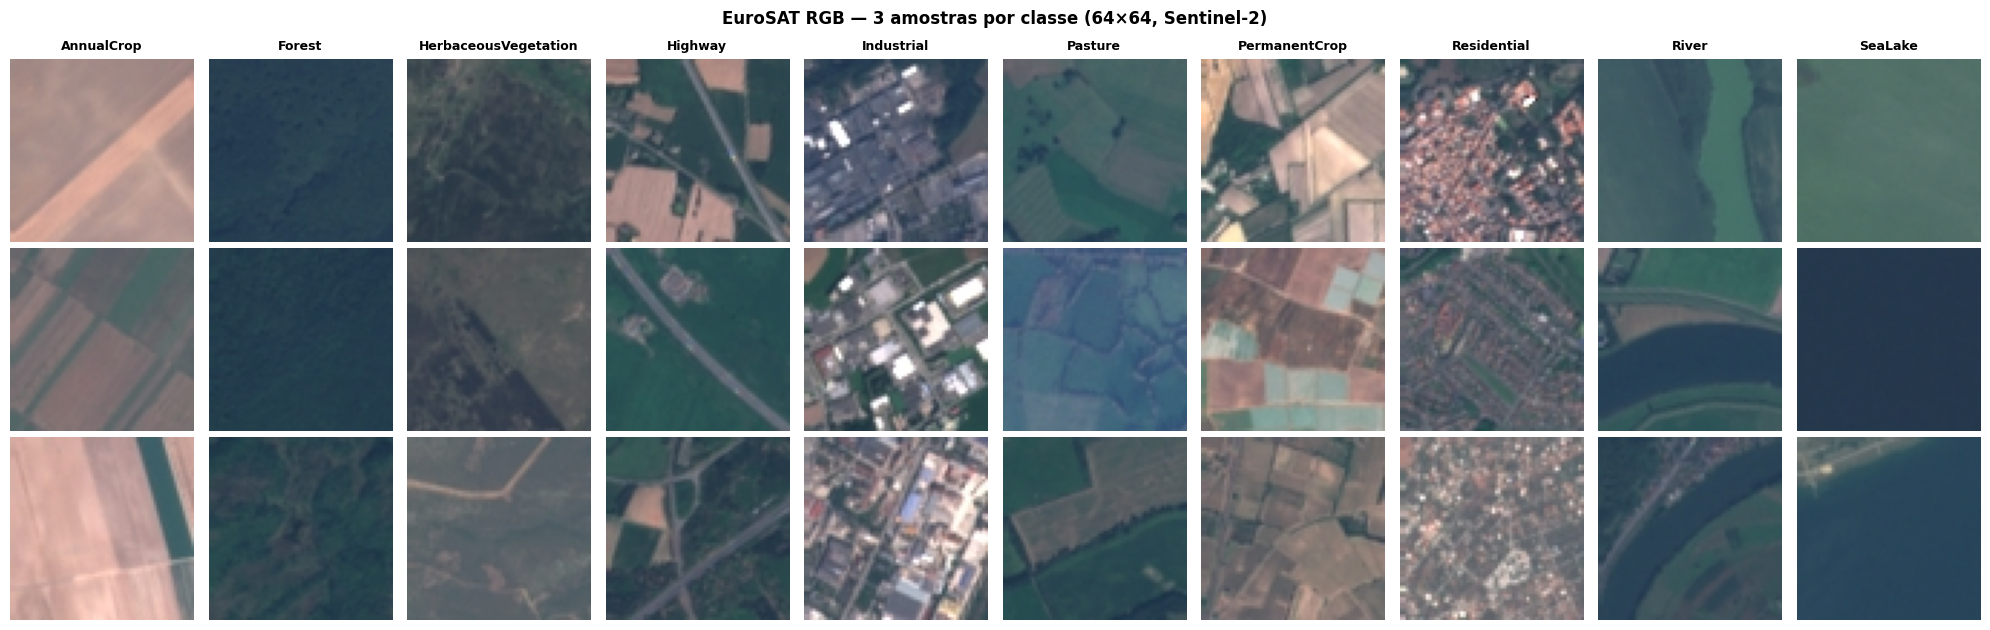

In [4]:
fig, axes = plt.subplots(3, NUM_CLASSES, figsize=(2 * NUM_CLASSES, 6.4))
y_tr = labels_by_split["train"]
for c in range(NUM_CLASSES):
    for r, idx in enumerate(np.where(y_tr == c)[0][:3]):
        axes[r, c].imshow(raw["train"][int(idx)]["image"])
        axes[r, c].axis("off")
    axes[0, c].set_title(class_names[c], fontsize=9, fontweight="bold")
plt.suptitle("EuroSAT RGB — 3 amostras por classe (64×64, Sentinel-2)", fontweight="bold")
plt.tight_layout(); savefig("amostras_classes.png"); plt.show()

**Leitura visual.** As classes se separam por **cor e textura** (verde homogêneo em *Forest*, azul liso em *SeaLake*,
malha de telhados em *Residential*/*Industrial*) e, em algumas, por **estruturas lineares longas** que atravessam o
*tile* (*Highway*, *River*). Os pares difíceis esperados são *AnnualCrop* × *PermanentCrop*, *Pasture* ×
*HerbaceousVegetation* e *Highway* × *River* — mesma paleta, diferença sutil de estrutura.

### 1.1 Dados em memória e augmentation

As 27.000 imagens cabem na RAM como tensores `uint8` (~330 MB). Carregá-las uma vez e fazer augmentation **na GPU**
elimina o gargalo de decodificação de PNG por época e deixa o treino do ViT do zero limitado apenas pelo modelo.

In [5]:
def to_tensors(ds, n=None):
    """Decodifica um split inteiro para tensores uint8 [N,3,64,64] + rótulos [N]."""
    if n is not None:
        ds = ds.shuffle(seed=SEED).select(range(min(n, len(ds))))
    imgs = np.stack([np.asarray(im.convert("RGB")) for im in ds["image"]])
    x = torch.from_numpy(imgs).permute(0, 3, 1, 2).contiguous()
    y = torch.tensor(np.array(ds["label"]), dtype=torch.long)
    return x, y

N_SMOKE = {"train": 512, "validation": 256, "test": 256}
t0 = time.time()
data = {s: to_tensors(raw[s], N_SMOKE[s] if SMOKE else None) for s in ("train", "validation", "test")}
print(f"Decodificação: {time.time() - t0:.1f}s")
for s, (x, y) in data.items():
    print(f"   {s:<10} x={tuple(x.shape)} {x.dtype} | y={tuple(y.shape)}")

# Estatísticas de normalização calculadas no TREINO (o ViT do zero não herda as do ImageNet)
xf = data["train"][0].float().div(255)
EUROSAT_MEAN = xf.mean(dim=(0, 2, 3)).tolist()
EUROSAT_STD = xf.std(dim=(0, 2, 3)).tolist()
del xf
print("mean:", np.round(EUROSAT_MEAN, 4), "| std:", np.round(EUROSAT_STD, 4))

# Subconjunto estratificado de 10% do treino para o experimento de poucos dados (§6.2)
idx_10, _ = train_test_split(np.arange(len(data["train"][1])), train_size=0.10,
                             stratify=data["train"][1].numpy(), random_state=SEED)
data["train_10"] = (data["train"][0][idx_10], data["train"][1][idx_10])
print(f"train_10: {len(idx_10)} imagens")

Decodificação: 17.0s
   train      x=(16200, 3, 64, 64) torch.uint8 | y=(16200,)
   validation x=(5400, 3, 64, 64) torch.uint8 | y=(5400,)
   test       x=(5400, 3, 64, 64) torch.uint8 | y=(5400,)
mean: [0.3448 0.3807 0.4082] | std: [0.2027 0.1371 0.1158]
train_10: 1620 imagens


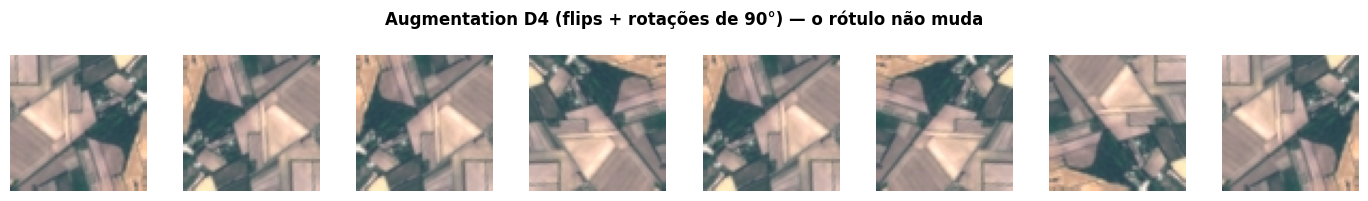

In [6]:
def augment_satellite(x):
    """Flips H/V + rotações de 90° por amostra (grupo diedral D4).

    Por quê: a imagem é vista de topo, sem orientação canônica — uma floresta girada 90° continua floresta.
    Essas 8 simetrias preservam o rótulo e multiplicam os dados sem criar artefatos. Não usamos color
    jitter: a cor espectral É evidência de classe (água × vegetação × solo exposto).
    """
    B = x.size(0)
    flip_h = torch.rand(B, device=x.device) < 0.5
    x = torch.where(flip_h[:, None, None, None], x.flip(-1), x)
    flip_v = torch.rand(B, device=x.device) < 0.5
    x = torch.where(flip_v[:, None, None, None], x.flip(-2), x)
    k = torch.randint(0, 4, (B,), device=x.device)
    out = x.clone()
    for r in (1, 2, 3):
        m = k == r
        if m.any():
            out[m] = torch.rot90(x[m], r, dims=(-2, -1))
    return out


def make_preprocess(mean, std, size=None):
    """uint8 [B,3,64,64] (CPU) → float normalizado na GPU, com augmentation opcional e resize opcional."""
    mean_t = torch.tensor(mean, device=device).view(1, 3, 1, 1)
    std_t = torch.tensor(std, device=device).view(1, 3, 1, 1)

    def prep(xb, train):
        x = xb.to(device, non_blocking=True).float().div_(255)
        if train:
            x = augment_satellite(x)
        if size is not None and x.shape[-1] != size:
            x = F.interpolate(x, size=(size, size), mode="bilinear", align_corners=False)
        return (x - mean_t) / std_t
    return prep


def iterate(x, y, batch_size, shuffle):
    idx = torch.randperm(len(x)) if shuffle else torch.arange(len(x))
    for i in range(0, len(x), batch_size):
        b = idx[i:i + batch_size]
        yield x[b], y[b]


# Visualização das 8 simetrias D4 aplicadas a uma imagem
x_demo = data["train"][0][:1].float().div(255).repeat(8, 1, 1, 1)
set_seed(0)
aug = augment_satellite(x_demo)
fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i, ax in enumerate(axes):
    ax.imshow(aug[i].permute(1, 2, 0).numpy()); ax.axis("off")
plt.suptitle("Augmentation D4 (flips + rotações de 90°) — o rótulo não muda", fontweight="bold")
plt.tight_layout(); savefig("augmentation_d4.png"); plt.show()
set_seed()

## 2. Attention do zero

Implementação modular seguindo a Aula 02, agora voltada a visão. Cada módulo é **testável** isoladamente e vem
acompanhado de testes (`assert`) logo abaixo.

### 2.1 Scaled dot-product attention

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{Q K^\top}{\sqrt{d_k}} + M\right) V$$

Dividir por $\sqrt{d_k}$ mantém a variância dos scores ≈ 1: sem isso, com $d_k$ grande, o softmax satura
(uma posição recebe peso ≈ 1) e o gradiente desaparece. $M$ é uma máscara opcional ($-\infty$ nas posições proibidas).

In [7]:
class ScaledDotProductAttention(nn.Module):
    """softmax(QKᵀ/√d_k + M)·V. Retorna (saída, pesos de atenção) — os pesos alimentam os heatmaps da §7."""

    def __init__(self, dropout=0.0):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

    def forward(self, q, k, v, mask=None):
        # q: [B, N_q, d_k] | k: [B, N_k, d_k] | v: [B, N_k, d_v]
        d_k = q.size(-1)
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)   # [B, N_q, N_k]
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))
        attn = F.softmax(scores, dim=-1)                                   # cada linha soma 1
        out = torch.matmul(self.dropout(attn), v)                          # [B, N_q, d_v]
        return out, attn

In [8]:
# ── Testes da scaled dot-product attention
torch.manual_seed(0)
sdpa = ScaledDotProductAttention()
q, k, v = torch.randn(2, 5, 16), torch.randn(2, 7, 16), torch.randn(2, 7, 32)
out, attn = sdpa(q, k, v)
assert out.shape == (2, 5, 32) and attn.shape == (2, 5, 7), "shapes incorretos"
assert torch.allclose(attn.sum(-1), torch.ones(2, 5)), "linhas da atenção não somam 1"

# Máscara: chaves mascaradas recebem peso exatamente zero
mask = torch.ones(2, 5, 7); mask[..., -2:] = 0
_, attn_m = sdpa(q, k, v, mask)
assert torch.all(attn_m[..., -2:] == 0) and torch.allclose(attn_m.sum(-1), torch.ones(2, 5))

# Equivalência com a implementação oficial do PyTorch
ref = F.scaled_dot_product_attention(q, k, v)
assert torch.allclose(out, ref, atol=1e-5), "diverge de F.scaled_dot_product_attention"
print("✅ ScaledDotProductAttention: shapes, soma das linhas = 1, máscara e equivalência com PyTorch OK")

✅ ScaledDotProductAttention: shapes, soma das linhas = 1, máscara e equivalência com PyTorch OK


### 2.2 Multi-head attention — projeções independentes por head + concatenação

$$\text{head}_i = \text{Attention}(X W_Q^{(i)},\; X W_K^{(i)},\; X W_V^{(i)}), \qquad
\text{MultiHead}(X) = \text{Concat}(\text{head}_1, \dots, \text{head}_h)\, W_O$$

Cada head tem **suas próprias** matrizes $W_Q^{(i)}, W_K^{(i)}, W_V^{(i)} \in \mathbb{R}^{d_{model} \times d_k}$
com $d_k = d_{model}/h$ — implementadas aqui como módulos `AttentionHead` separados, o que deixa explícito que cada
head aprende um subespaço diferente (uma pode olhar textura, outra bordas lineares). A Aula 02 usa uma única
`nn.Linear(d_model, d_model)` seguida de `view` para separar as heads; **as duas formas são matematicamente
equivalentes** (a matriz grande é a concatenação das pequenas), e o teste abaixo prova isso copiando nossos pesos
para o `nn.MultiheadAttention` oficial e comparando as saídas.

In [9]:
class AttentionHead(nn.Module):
    """Uma head: projeções W_Q, W_K, W_V PRÓPRIAS (d_model → d_k) + scaled dot-product attention."""

    def __init__(self, d_model, d_k, dropout=0.0):
        super().__init__()
        self.w_q = nn.Linear(d_model, d_k)
        self.w_k = nn.Linear(d_model, d_k)
        self.w_v = nn.Linear(d_model, d_k)
        self.attention = ScaledDotProductAttention(dropout)

    def forward(self, x_q, x_k, x_v, mask=None):
        return self.attention(self.w_q(x_q), self.w_k(x_k), self.w_v(x_v), mask)


class MultiHeadAttention(nn.Module):
    """h heads independentes → concatenação das saídas → projeção W_O."""

    def __init__(self, d_model, n_heads, dropout=0.0):
        super().__init__()
        assert d_model % n_heads == 0, "d_model deve ser divisível por n_heads"
        self.n_heads, self.d_k = n_heads, d_model // n_heads
        self.heads = nn.ModuleList([AttentionHead(d_model, self.d_k, dropout) for _ in range(n_heads)])
        self.w_o = nn.Linear(d_model, d_model)

    def forward(self, q, k, v, mask=None):
        outs, attns = zip(*(head(q, k, v, mask) for head in self.heads))
        concat = torch.cat(outs, dim=-1)                  # [B, N, h·d_k] = [B, N, d_model]
        return self.w_o(concat), torch.stack(attns, 1)    # pesos: [B, h, N_q, N_k]

In [10]:
# ── Testes da multi-head attention
torch.manual_seed(0)
d_model, n_heads = 64, 4
mha = MultiHeadAttention(d_model, n_heads).eval()
x = torch.randn(3, 10, d_model)
out, attn = mha(x, x, x)
assert out.shape == (3, 10, d_model) and attn.shape == (3, n_heads, 10, 10)

# 1) Projeções independentes: 3·h matrizes distintas, cada uma d_model → d_k
proj = [p for h in mha.heads for p in (h.w_q.weight, h.w_k.weight, h.w_v.weight)]
assert len(proj) == 3 * n_heads and all(p.shape == (d_model // n_heads, d_model) for p in proj)
assert len({p.data_ptr() for p in proj}) == len(proj), "heads compartilhando pesos"

# 2) Gradiente chega em todas as heads
out.sum().backward()
assert all(h.w_q.weight.grad is not None and h.w_q.weight.grad.abs().sum() > 0 for h in mha.heads)

# 3) Equivalência com nn.MultiheadAttention: concatenar os W_Q/W_K/W_V das heads = matriz única da Aula 02
ref = nn.MultiheadAttention(d_model, n_heads, batch_first=True).eval()
with torch.no_grad():
    cat_w = lambda name: torch.cat([getattr(h, name).weight for h in mha.heads], 0)
    cat_b = lambda name: torch.cat([getattr(h, name).bias for h in mha.heads], 0)
    ref.in_proj_weight.copy_(torch.cat([cat_w("w_q"), cat_w("w_k"), cat_w("w_v")], 0))
    ref.in_proj_bias.copy_(torch.cat([cat_b("w_q"), cat_b("w_k"), cat_b("w_v")], 0))
    ref.out_proj.weight.copy_(mha.w_o.weight); ref.out_proj.bias.copy_(mha.w_o.bias)
    out_ref, attn_ref = ref(x, x, x, need_weights=True, average_attn_weights=False)
    out_ours, attn_ours = mha(x, x, x)
assert torch.allclose(out_ours, out_ref, atol=1e-5) and torch.allclose(attn_ours, attn_ref, atol=1e-6)
print("✅ MultiHeadAttention: shapes, 3·h projeções independentes, gradiente por head e "
      "equivalência numérica com nn.MultiheadAttention OK")

✅ MultiHeadAttention: shapes, 3·h projeções independentes, gradiente por head e equivalência numérica com nn.MultiheadAttention OK


### 2.3 `TransformerEncoderBlock` — FFN de 2 camadas + LayerNorm + residual connections

Arquitetura **Pre-LN** (Aula 02 e ViT original): a LayerNorm vem **antes** de cada subcamada e a conexão residual
soma a entrada intacta, o que mantém um caminho de gradiente identidade através de toda a pilha e estabiliza o
treino sem precisar de warmup longo:

$$x' = x + \text{MHA}(\text{LN}(x)), \qquad y = x' + \text{FFN}(\text{LN}(x')), \qquad
\text{FFN}(z) = \text{GELU}(z W_1 + b_1) W_2 + b_2$$

A FFN expande a dimensão 4× ($d_{ff} = 4\,d_{model}$) e é aplicada a cada token independentemente: a atenção
**mistura** informação entre tokens, a FFN **transforma** cada token.

In [11]:
class FeedForward(nn.Module):
    """MLP de 2 camadas aplicada a cada token: d_model → d_ff (GELU) → d_model."""

    def __init__(self, d_model, d_ff, dropout=0.0):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.act = nn.GELU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.linear2(self.dropout(self.act(self.linear1(x))))


class TransformerEncoderBlock(nn.Module):
    """Bloco Pre-LN: x + MHA(LN(x)) → x + FFN(LN(x)). Retorna (x, pesos de atenção)."""

    def __init__(self, d_model, n_heads, d_ff, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        h = self.norm1(x)
        attn_out, attn = self.attn(h, h, h)
        x = x + self.dropout(attn_out)                      # residual 1
        x = x + self.dropout(self.ffn(self.norm2(x)))       # residual 2
        return x, attn

In [12]:
# ── Testes do TransformerEncoderBlock
torch.manual_seed(0)
blk = TransformerEncoderBlock(d_model=64, n_heads=4, d_ff=256).eval()
x = torch.randn(2, 10, 64)
y, attn = blk(x)
assert y.shape == x.shape and attn.shape == (2, 4, 10, 10)
assert len([m for m in blk.ffn.modules() if isinstance(m, nn.Linear)]) == 2, "FFN deve ter 2 camadas"
assert sum(isinstance(m, nn.LayerNorm) for m in blk.modules()) == 2

# Residual: zerando as saídas das duas subcamadas o bloco vira a identidade
with torch.no_grad():
    for lin in (blk.attn.w_o, blk.ffn.linear2):
        lin.weight.zero_(); lin.bias.zero_()
    y0, _ = blk(x)
assert torch.allclose(y0, x), "conexões residuais ausentes"
print("✅ TransformerEncoderBlock: shape preservado, FFN de 2 camadas, 2 LayerNorms e residual (identidade) OK")

✅ TransformerEncoderBlock: shape preservado, FFN de 2 camadas, 2 LayerNorms e residual (identidade) OK


## 3. ViT do zero

```
imagem 3×64×64 ─► PatchEmbedding (Conv2d k=8, s=8) ─► 64 tokens × 192
                  [CLS] aprendível concatenado      ─► 65 tokens × 192
                  + positional embedding aprendível ─► 65 tokens × 192
                  6 × TransformerEncoderBlock (6 heads, d_ff = 768)
                  LayerNorm ─► token [CLS] ─► Linear(192, 10) ─► logits
```

- **Patch embedding**: `Conv2d(3, d, kernel=p, stride=p)` é exatamente "recortar patches p×p, achatar e aplicar a
  mesma `nn.Linear`" (mesma forma do `ViTForImageClassification` da Aula 04) — provado no teste abaixo.
- **Token `[CLS]`**: vetor aprendível que não corresponde a nenhum patch; por atenção ele agrega a imagem inteira e
  sua saída final alimenta o classification head.
- **Positional encoding**: tabela **aprendível** `[1, 65, d]` somada aos tokens (padrão do ViT; a Aula 03 mostra a
  mesma ideia com `nn.Embedding(max_len, d)`). É 1D — o modelo precisa *aprender* a topologia 2D da grade (verificado
  na §7.4).

### 3.1 Por que attention sem positional encoding não preserva posição

A self-attention é uma função de **conjunto**, não de sequência. Seja $P$ uma matriz de permutação aplicada aos
tokens $X$. Como $Q=XW_Q$, $K=XW_K$, $V=XW_V$ são aplicadas token a token,

$$\text{softmax}\!\left(\frac{(PQ)(PK)^\top}{\sqrt{d_k}}\right)(PV) = P\,\text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)P^\top P\,V
= P\cdot\text{Attention}(Q,K,V)$$

(o softmax por linha comuta com permutações e $P^\top P = I$). Logo a atenção é **equivariante** a permutações:
embaralhar a entrada só embaralha a saída do mesmo jeito. LayerNorm, FFN e residual também agem token a token, então
o encoder inteiro é equivariante — e o token `[CLS]`, que agrega todos os outros por média ponderada, fica
**invariante**: ele recebe exatamente o mesmo conjunto de pares (chave, valor), só que em outra ordem. Para o modelo,
uma imagem e a mesma imagem com os patches embaralhados são **indistinguíveis** — ele vê um "saco de patches".

Somar $E_{pos}$ quebra essa simetria: o token do patch $j$ passa a ser $x_j + e_j$, então mover o conteúdo para
outra posição muda o vetor que entra na atenção. O código abaixo demonstra os dois casos.

In [13]:
class PatchEmbedding(nn.Module):
    """Imagem [B,3,H,W] → tokens [B, N, d_model], N = (H/p)·(W/p). Conv com stride = kernel = projeção linear por patch."""

    def __init__(self, img_size=64, patch_size=8, in_chans=3, d_model=192):
        super().__init__()
        self.patch_size = patch_size
        self.grid = img_size // patch_size
        self.n_patches = self.grid ** 2
        self.proj = nn.Conv2d(in_chans, d_model, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        return self.proj(x).flatten(2).transpose(1, 2)    # [B, d, g, g] → [B, g·g, d]


class ViT(nn.Module):
    """Vision Transformer completo construído sobre os módulos da §2: imagem → logits."""

    def __init__(self, img_size=64, patch_size=8, num_classes=10, d_model=192, depth=6,
                 n_heads=6, d_ff=768, dropout=0.1, use_pos_embed=True):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, 3, d_model)
        n_tokens = self.patch_embed.n_patches + 1
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_tokens, d_model)) if use_pos_embed else None
        self.pos_drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([TransformerEncoderBlock(d_model, n_heads, d_ff, dropout) for _ in range(depth)])
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, num_classes)
        self._init_weights()

    def _init_weights(self):
        # Inicialização do ViT/DeiT: normal truncada σ=0,02 em tokens aprendíveis e camadas lineares
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        if self.pos_embed is not None:
            nn.init.trunc_normal_(self.pos_embed, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x, return_attn=False):
        x = self.patch_embed(x)                                        # [B, 64, d]
        x = torch.cat([self.cls_token.expand(x.size(0), -1, -1), x], 1)  # [B, 65, d]
        if self.pos_embed is not None:
            x = x + self.pos_embed
        x = self.pos_drop(x)
        attns = []
        for blk in self.blocks:
            x, attn = blk(x)
            attns.append(attn)
        logits = self.head(self.norm(x)[:, 0])                         # classificação pelo [CLS]
        return (logits, attns) if return_attn else logits


VIT_CFG = dict(img_size=64, patch_size=8, num_classes=NUM_CLASSES, d_model=192, depth=6,
               n_heads=6, d_ff=768, dropout=0.1)

def count_params(m, trainable_only=False):
    return sum(p.numel() for p in m.parameters() if p.requires_grad or not trainable_only)

set_seed()
_vit = ViT(**VIT_CFG)
logits, attns = _vit(torch.randn(2, 3, 64, 64), return_attn=True)
assert logits.shape == (2, NUM_CLASSES) and len(attns) == 6 and attns[0].shape == (2, 6, 65, 65)
print(f"✅ ViT: imagem [2,3,64,64] → logits {tuple(logits.shape)} | "
      f"{count_params(_vit) / 1e6:.2f} M parâmetros | atenção por bloco {tuple(attns[0].shape)}")

# Patch embedding = recortar patches + Linear compartilhada
pe = _vit.patch_embed
xx = torch.randn(2, 3, 64, 64)
patches = F.unfold(xx, kernel_size=8, stride=8).transpose(1, 2)              # [B, 64, 192]
lin = patches @ pe.proj.weight.flatten(1).T + pe.proj.bias
assert torch.allclose(pe(xx), lin, atol=1e-5)
print("✅ PatchEmbedding (Conv2d k=s=8) ≡ unfold em patches 8×8 + projeção linear compartilhada")

✅ ViT: imagem [2,3,64,64] → logits (2, 10) | 2.72 M parâmetros | atenção por bloco (2, 6, 65, 65)
✅ PatchEmbedding (Conv2d k=s=8) ≡ unfold em patches 8×8 + projeção linear compartilhada


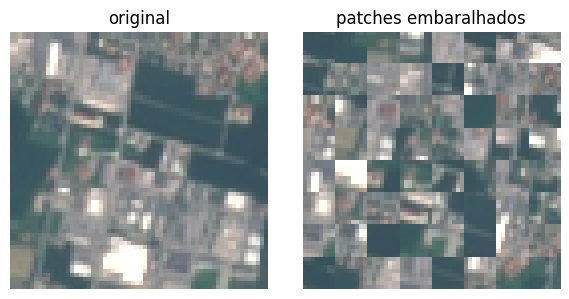

Sem PE — máx |Δlogits| original × embaralhada: 3.28e-07  → invariante (mesma predição)
Com PE — máx |Δlogits| original × embaralhada: 1.17e-03  → posição importa
Tokens de patch sem PE são permutados junto com a entrada (equivariância): True


In [14]:
def shuffle_patches(x, p, perm):
    """Reordena os patches p×p de um batch de imagens segundo `perm` (mesma permutação para todas)."""
    B, C, H, W = x.shape
    gh, gw = H // p, W // p
    t = x.reshape(B, C, gh, p, gw, p).permute(0, 2, 4, 1, 3, 5).reshape(B, gh * gw, C, p, p)
    t = t[:, perm]
    return t.reshape(B, gh, gw, C, p, p).permute(0, 3, 1, 4, 2, 5).reshape(B, C, H, W)

set_seed()
img = data["test"][0][:1].float().div(255)
perm = torch.randperm(64)
img_shuf = shuffle_patches(img, 8, perm)

vit_nope = ViT(**{**VIT_CFG, "use_pos_embed": False}).eval()
vit_pe = ViT(**VIT_CFG).eval()
with torch.no_grad():
    d_nope = (vit_nope(img) - vit_nope(img_shuf)).abs().max().item()
    d_pe = (vit_pe(img) - vit_pe(img_shuf)).abs().max().item()
    # Equivariância dos tokens de patch: saída embaralhada = embaralhamento da saída
    tok = lambda m, im: m.blocks[0](torch.cat([m.cls_token, m.patch_embed(im)], 1))[0]
    t_orig, t_shuf = tok(vit_nope, img), tok(vit_nope, img_shuf)
    equiv = torch.allclose(t_shuf[:, 1:], t_orig[:, 1:][:, perm], atol=1e-5)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
for ax, im, t in zip(axes, (img, img_shuf), ("original", "patches embaralhados")):
    ax.imshow(im[0].permute(1, 2, 0)); ax.set_title(t); ax.axis("off")
plt.tight_layout(); savefig("permutacao_patches.png"); plt.show()

print(f"Sem PE — máx |Δlogits| original × embaralhada: {d_nope:.2e}  → invariante (mesma predição)")
print(f"Com PE — máx |Δlogits| original × embaralhada: {d_pe:.2e}  → posição importa")
print(f"Tokens de patch sem PE são permutados junto com a entrada (equivariância): {equiv}")
assert d_nope < 1e-4 and d_pe > 1e-4 and equiv

**Resultado.** Sem PE, os logits da imagem original e da imagem com os 64 patches embaralhados são **idênticos**
(diferença na ordem de $10^{-7}$, erro de ponto flutuante) — o modelo literalmente não consegue distinguir as duas.
Com PE a saída muda. O efeito disso num modelo **treinado** é medido na §4.2 (ablação sem PE) e na §6.3 (avaliação
em imagens de teste embaralhadas).

## 4. Treino do ViT do zero

Loop de treino em PyTorch puro, no padrão das Aulas 02/03 (AdamW + agendador cossenoidal + gradient clipping),
com dois acréscimos necessários para ViT do zero: **warmup linear** (os primeiros passos de um Transformer com pesos
aleatórios são instáveis com LR alto) e **mixed precision fp16** na T4. O mesmo loop é reutilizado no fine-tuning
(§5), o que torna a comparação controlada: mesmos dados, mesma augmentation, mesmas métricas.

| Hiperparâmetro | Valor | Justificativa |
|---|---|---|
| Patch | 8×8 → 64 tokens | patch 16 daria só 16 tokens (4×4) — grosseiro demais para 64 px; patch 4 daria 256 tokens e 16× o custo de atenção |
| $d_{model}$ / heads / profundidade | 192 / 6 ($d_k$=32) / 6 | largura do ViT-Tiny/DeiT-Ti, metade da profundidade: ~2,7 M parâmetros para 16 mil imagens (ViT é *data hungry*; capacidade maior só memorizaria) |
| $d_{ff}$ | 768 (4×) | razão padrão do Transformer |
| Otimizador | AdamW, LR 1e-3, weight decay 0,05 | LR alto é viável com Pre-LN + warmup; weight decay forte como regularizador (receita DeiT) |
| Agenda | 5 épocas de warmup linear + cosseno até 0 | estabiliza o início e refina no final |
| Épocas / batch | 50 / 128 | tempo suficiente para a agenda cossenoidal convergir (a validação estabiliza nas últimas épocas); o melhor checkpoint é escolhido na validação |
| Regularização | dropout 0,1, label smoothing 0,1, augmentation D4, clipping 1,0 | compensa a ausência de viés indutivo (localidade) do ViT |

In [15]:
def lr_lambda_factory(total_steps, warmup_steps):
    def f(step):
        if step < warmup_steps:
            return (step + 1) / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1 + math.cos(math.pi * progress))
    return f


@torch.no_grad()
def predict(model, logits_fn, prep, x, y, batch_size=256):
    model.eval()
    preds, loss_sum = [], 0.0
    for xb, yb in iterate(x, y, batch_size, shuffle=False):
        with torch.autocast(device.type, dtype=torch.float16, enabled=USE_AMP):
            logits = logits_fn(model, prep(xb, train=False))
        loss_sum += F.cross_entropy(logits.float(), yb.to(device), reduction="sum").item()
        preds.append(logits.argmax(-1).cpu())
    preds = torch.cat(preds)
    return loss_sum / len(y), (preds == y).float().mean().item(), preds


def train_model(model, logits_fn, prep, train_xy, val_xy, *, name, epochs, lr, weight_decay,
                batch_size, warmup_epochs, label_smoothing=0.0):
    """Treina com AdamW + warmup/cosseno + AMP; guarda o melhor checkpoint pela accuracy de validação."""
    model.to(device)
    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=lr, weight_decay=weight_decay)
    steps_per_epoch = math.ceil(len(train_xy[0]) / batch_size)
    sched = torch.optim.lr_scheduler.LambdaLR(
        opt, lr_lambda_factory(epochs * steps_per_epoch, int(warmup_epochs * steps_per_epoch)))
    scaler = torch.amp.GradScaler(device.type, enabled=USE_AMP)
    hist = {k: [] for k in ("train_loss", "train_acc", "val_loss", "val_acc", "lr")}
    best = {"val_acc": -1.0}
    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats(); torch.cuda.synchronize()
    t0 = time.time()
    for ep in range(1, epochs + 1):
        model.train()
        loss_sum, correct, seen = 0.0, 0, 0
        for xb, yb in iterate(*train_xy, batch_size, shuffle=True):
            xb, yb = prep(xb, train=True), yb.to(device)
            with torch.autocast(device.type, dtype=torch.float16, enabled=USE_AMP):
                logits = logits_fn(model, xb)
            loss = F.cross_entropy(logits.float(), yb, label_smoothing=label_smoothing)
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(opt); scaler.update(); sched.step()
            loss_sum += loss.item() * len(yb)
            correct += (logits.argmax(-1) == yb).sum().item()
            seen += len(yb)
        val_loss, val_acc, _ = predict(model, logits_fn, prep, *val_xy)
        for k, v in zip(hist, (loss_sum / seen, correct / seen, val_loss, val_acc, sched.get_last_lr()[0])):
            hist[k].append(v)
        flag = ""
        if val_acc > best["val_acc"]:
            best = {"val_acc": val_acc, "epoch": ep,
                    "state": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}}
            flag = " ⭐"
        print(f"[{name}] época {ep:02d}/{epochs} | treino loss {hist['train_loss'][-1]:.4f} "
              f"acc {hist['train_acc'][-1]:.4f} | val loss {val_loss:.4f} acc {val_acc:.4f}{flag}")
    if device.type == "cuda":
        torch.cuda.synchronize()
    train_time = time.time() - t0
    model.load_state_dict(best["state"])
    torch.save(best["state"], CKPT_DIR / f"{name}_best.pt")
    info = {"train_time_s": train_time, "epochs": epochs, "best_epoch": best["epoch"],
            "best_val_acc": best["val_acc"],
            "peak_vram_gb": torch.cuda.max_memory_allocated() / 1024**3 if device.type == "cuda" else float("nan")}
    print(f"✅ {name}: {train_time / 60:.1f} min | melhor época {best['epoch']} (val acc {best['val_acc']:.4f})")
    return hist, info


def plot_history(hist, title, fname):
    ep = range(1, len(hist["train_loss"]) + 1)
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
    a1.plot(ep, hist["train_loss"], label="treino"); a1.plot(ep, hist["val_loss"], label="validação")
    a1.set_title("Loss (cross-entropy)"); a1.set_xlabel("época"); a1.legend(); a1.grid(alpha=.3)
    a2.plot(ep, hist["train_acc"], label="treino"); a2.plot(ep, hist["val_acc"], label="validação")
    a2.set_title("Accuracy"); a2.set_xlabel("época"); a2.legend(); a2.grid(alpha=.3)
    plt.suptitle(title, fontweight="bold"); plt.tight_layout(); savefig(fname); plt.show()


SCRATCH_HP = dict(epochs=2 if SMOKE else 50, lr=1e-3, weight_decay=0.05, batch_size=128,
                  warmup_epochs=1 if SMOKE else 5, label_smoothing=0.1)
prep_scratch = make_preprocess(EUROSAT_MEAN, EUROSAT_STD)
logits_scratch = lambda m, x: m(x)
RESULTS = {}   # nome → dict com hist, info, modelo

[vit_scratch] época 01/50 | treino loss 1.6533 acc 0.4818 | val loss 1.0868 acc 0.6196 ⭐
[vit_scratch] época 02/50 | treino loss 1.1572 acc 0.7045 | val loss 0.8858 acc 0.7017 ⭐
[vit_scratch] época 03/50 | treino loss 1.0460 acc 0.7590 | val loss 0.6804 acc 0.7806 ⭐
[vit_scratch] época 04/50 | treino loss 0.9955 acc 0.7805 | val loss 0.6202 acc 0.7970 ⭐
[vit_scratch] época 05/50 | treino loss 0.9690 acc 0.7917 | val loss 0.7030 acc 0.7650
[vit_scratch] época 06/50 | treino loss 0.9346 acc 0.8062 | val loss 0.6128 acc 0.8052 ⭐
[vit_scratch] época 07/50 | treino loss 0.9174 acc 0.8131 | val loss 0.5508 acc 0.8296 ⭐
[vit_scratch] época 08/50 | treino loss 0.8843 acc 0.8288 | val loss 0.5804 acc 0.8169
[vit_scratch] época 09/50 | treino loss 0.8618 acc 0.8381 | val loss 0.4792 acc 0.8539 ⭐
[vit_scratch] época 10/50 | treino loss 0.8376 acc 0.8514 | val loss 0.4888 acc 0.8507
[vit_scratch] época 11/50 | treino loss 0.8168 acc 0.8622 | val loss 0.5010 acc 0.8457
[vit_scratch] época 12/50 | t

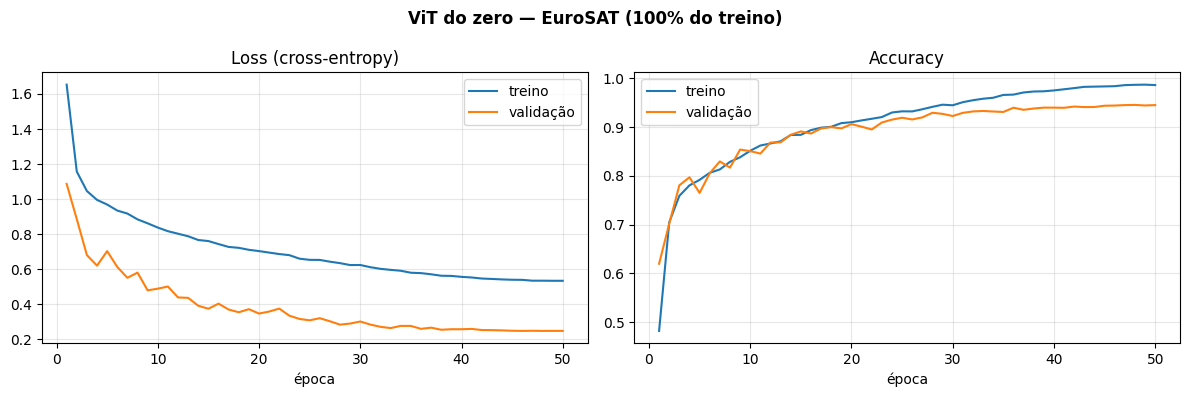

In [16]:
set_seed()
vit_scratch = ViT(**VIT_CFG)
hist, info = train_model(vit_scratch, logits_scratch, prep_scratch, data["train"], data["validation"],
                         name="vit_scratch", **SCRATCH_HP)
RESULTS["ViT do zero"] = dict(model=vit_scratch, hist=hist, info=info, logits_fn=logits_scratch,
                              prep=prep_scratch, pretrain="—", train_data="100% (16.200)")
plot_history(hist, "ViT do zero — EuroSAT (100% do treino)", "curvas_vit_scratch.png")

### 4.1 Leitura das curvas

- **Convergência.** A accuracy de validação sobe de forma consistente até o fim: melhor época **48/50**
  (val acc 0,9456), com a loss de validação estabilizada em ~0,248 nas últimas 5 épocas. A agenda cossenoidal levou o
  LR a ~0 e o modelo convergiu — mais épocas com a mesma receita trariam pouco.
- **Sobreajuste controlado.** O *gap* de accuracy cresce na segunda metade (0,986 no treino × 0,945 na validação na
  época 50), mas a loss de validação **não sobe**: a regularização (D4, dropout, label smoothing) conteve a
  memorização.
- **Loss de treino acima da de validação** (~0,53 × ~0,25): esperado, porque o treino é medido com augmentation,
  dropout e label smoothing ativos (o alvo suavizado impede a loss de ir a zero), e a validação sem nenhum deles.

### 4.2 Ablação — o mesmo ViT **sem** positional encoding

Mesma arquitetura, mesmos hiperparâmetros, mesma semente; só removemos `pos_embed`. A §3.1 mostrou que esse modelo
é cego à posição dos patches: a diferença de accuracy entre os dois mede **quanto a configuração espacial dos patches
importa** neste domínio (em relação a apenas "quais texturas aparecem").

[vit_scratch_nope] época 01/50 | treino loss 1.6526 acc 0.4800 | val loss 1.0538 acc 0.6274 ⭐
[vit_scratch_nope] época 02/50 | treino loss 1.1519 acc 0.7091 | val loss 0.7443 acc 0.7593 ⭐
[vit_scratch_nope] época 03/50 | treino loss 1.0460 acc 0.7575 | val loss 0.7909 acc 0.7206
[vit_scratch_nope] época 04/50 | treino loss 0.9890 acc 0.7823 | val loss 0.6339 acc 0.8020 ⭐
[vit_scratch_nope] época 05/50 | treino loss 0.9808 acc 0.7838 | val loss 0.6786 acc 0.7798
[vit_scratch_nope] época 06/50 | treino loss 0.9423 acc 0.8060 | val loss 0.5923 acc 0.8204 ⭐
[vit_scratch_nope] época 07/50 | treino loss 0.9369 acc 0.8051 | val loss 0.5645 acc 0.8241 ⭐
[vit_scratch_nope] época 08/50 | treino loss 0.9009 acc 0.8188 | val loss 0.5305 acc 0.8439 ⭐
[vit_scratch_nope] época 09/50 | treino loss 0.8642 acc 0.8415 | val loss 0.5332 acc 0.8378
[vit_scratch_nope] época 10/50 | treino loss 0.8581 acc 0.8425 | val loss 0.5167 acc 0.8406
[vit_scratch_nope] época 11/50 | treino loss 0.8440 acc 0.8471 | val

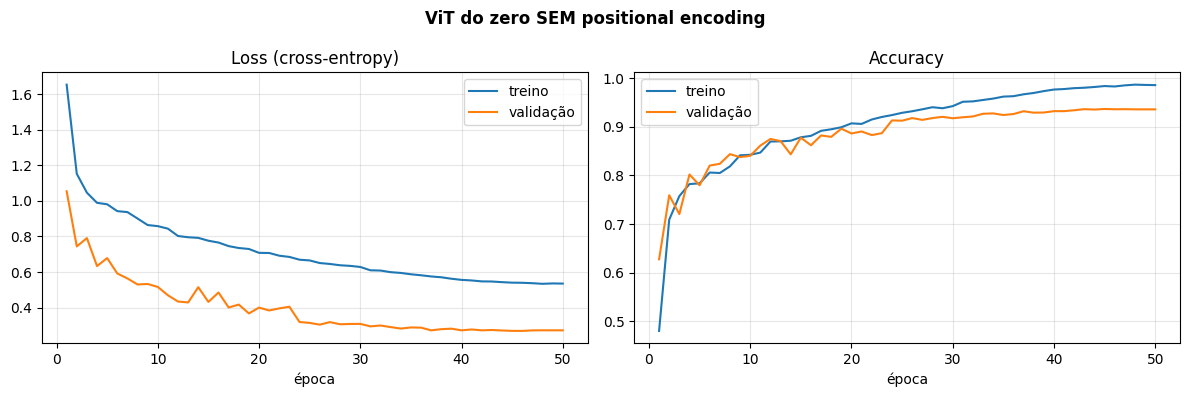

In [17]:
set_seed()
vit_nope = ViT(**{**VIT_CFG, "use_pos_embed": False})
hist, info = train_model(vit_nope, logits_scratch, prep_scratch, data["train"], data["validation"],
                         name="vit_scratch_nope", **SCRATCH_HP)
RESULTS["ViT do zero sem PE"] = dict(model=vit_nope, hist=hist, info=info, logits_fn=logits_scratch,
                                    prep=prep_scratch, pretrain="—", train_data="100% (16.200)")
plot_history(hist, "ViT do zero SEM positional encoding", "curvas_vit_scratch_sem_pe.png")

## 5. Fine-tuning de ViT pré-treinado (substituindo o classification head)

Mesmo checkpoint da Aula 05 no EuroSAT: **`google/vit-base-patch16-224-in21k`** — ViT-B/16 (86 M parâmetros, 12
blocos, 12 heads, $d$=768) pré-treinado de forma **supervisionada** nas 21.843 classes do ImageNet-21k (14 M de
imagens).

- **Substituição do head**: `AutoModelForImageClassification` com `num_labels=10` descarta o head de pré-treino e
  cria um `nn.Linear(768, 10)` novo, inicializado aleatoriamente; o corpo (patch embedding, `[CLS]`, position
  embeddings, 12 blocos) mantém os pesos pré-treinados.
- **Pré-processamento**: `AutoImageProcessor` do checkpoint (Aula 05) fornece resolução (224) e normalização
  (média/desvio do pré-treino). Reproduzimos o mesmo resize bilinear 64→224 e a mesma normalização na GPU, somando a
  augmentation D4 — assim os dois modelos veem exatamente as mesmas imagens.
- **`attn_implementation="eager"`** (Aula 04) para podermos extrair os pesos de atenção na §7.

| Hiperparâmetro | Valor | Justificativa |
|---|---|---|
| LR | 5e-5 (Aula 05), warmup de 10% + cosseno | 20× menor que no zero: os pesos já são bons; LR alto destruiria as features pré-treinadas (*catastrophic forgetting*) |
| Weight decay | 0,01 | regularização leve — o pré-treino já é o regularizador principal |
| Épocas / batch | 3 / 32 | converge em poucas épocas; batch 32 em fp16 cabe folgado nos 15 GB da T4 |
| Estratégia | fine-tuning completo | domínio (vista de satélite) distante do ImageNet → ajustar também o corpo, não só o head (ver §8.3) |

In [18]:
PT_CHECKPOINT = "google/vit-base-patch16-224-in21k"
processor = AutoImageProcessor.from_pretrained(PT_CHECKPOINT)
PT_SIZE = processor.size["height"]
print(f"Processor: {processor.__class__.__name__} | resolução {PT_SIZE} | "
      f"mean {processor.image_mean} | std {processor.image_std}")

def load_pretrained():
    return AutoModelForImageClassification.from_pretrained(
        PT_CHECKPOINT, num_labels=NUM_CLASSES, id2label=id2label, label2id=label2id,
        attn_implementation="eager")

set_seed()
vit_pt = load_pretrained()
print(f"🧠 Novo classification head: {vit_pt.classifier}")
print(f"   Parâmetros: {count_params(vit_pt) / 1e6:.1f} M | position embeddings "
      f"{tuple(vit_pt.vit.embeddings.position_embeddings.shape)} | [CLS] {tuple(vit_pt.vit.embeddings.cls_token.shape)}")

prep_pt = make_preprocess(processor.image_mean, processor.image_std, size=PT_SIZE)
logits_pt = lambda m, x: m(pixel_values=x).logits
PT_HP = dict(epochs=1 if SMOKE else 3, lr=5e-5, weight_decay=0.01, batch_size=8 if SMOKE else 32,
             warmup_epochs=0.1 if SMOKE else 0.3, label_smoothing=0.0)

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

Processor: ViTImageProcessor | resolução 224 | mean (0.5, 0.5, 0.5) | std (0.5, 0.5, 0.5)


model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


🧠 Novo classification head: Linear(in_features=768, out_features=10, bias=True)
   Parâmetros: 85.8 M | position embeddings (1, 197, 768) | [CLS] (1, 1, 768)


[vit_pretrained] época 01/3 | treino loss 0.6512 acc 0.8809 | val loss 0.1583 acc 0.9720 ⭐
[vit_pretrained] época 02/3 | treino loss 0.1071 acc 0.9815 | val loss 0.0835 acc 0.9833 ⭐
[vit_pretrained] época 03/3 | treino loss 0.0525 acc 0.9933 | val loss 0.0689 acc 0.9874 ⭐
✅ vit_pretrained: 10.5 min | melhor época 3 (val acc 0.9874)


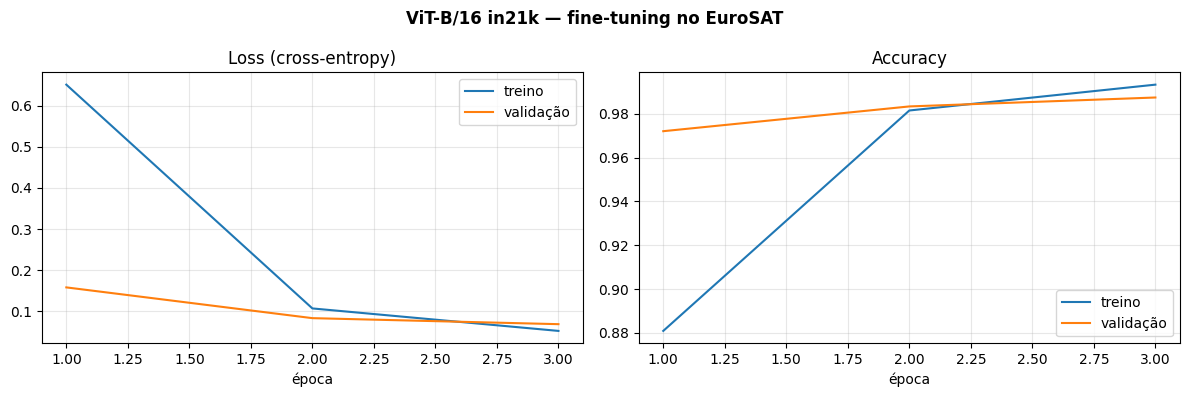

In [19]:
hist, info = train_model(vit_pt, logits_pt, prep_pt, data["train"], data["validation"],
                         name="vit_pretrained", **PT_HP)
RESULTS["ViT-B/16 pré-treinado (FT)"] = dict(model=vit_pt, hist=hist, info=info, logits_fn=logits_pt,
                                            prep=prep_pt, pretrain="ImageNet-21k", train_data="100% (16.200)")
plot_history(hist, "ViT-B/16 in21k — fine-tuning no EuroSAT", "curvas_vit_pretrained.png")

## 6. Tabela comparativa: do zero × pré-treinado

### 6.1 Regime de poucos dados (10% do treino)

Para justificar a arquitetura **com base nos dados**, repetimos os dois treinos com um subconjunto estratificado de
10% do treino (1.620 imagens, 162 por classe) — o tamanho típico de um projeto real de sensoriamento remoto com
rotulagem manual. Validação e teste continuam completos. Mantemos exatamente a mesma receita de cada modelo (mesmas
épocas, portanto 10× menos passos de otimização): o objetivo é isolar o efeito da **quantidade de dados rotulados**.

In [20]:
set_seed()
vit_scratch_10 = ViT(**VIT_CFG)
hist, info = train_model(vit_scratch_10, logits_scratch, prep_scratch, data["train_10"], data["validation"],
                         name="vit_scratch_10pct", **SCRATCH_HP)
RESULTS["ViT do zero (10% dados)"] = dict(model=vit_scratch_10, hist=hist, info=info, logits_fn=logits_scratch,
                                         prep=prep_scratch, pretrain="—", train_data="10% (1.620)")

set_seed()
vit_pt_10 = load_pretrained()
hist, info = train_model(vit_pt_10, logits_pt, prep_pt, data["train_10"], data["validation"],
                         name="vit_pretrained_10pct", **PT_HP)
RESULTS["ViT-B/16 pré-treinado (FT, 10% dados)"] = dict(model=vit_pt_10, hist=hist, info=info, logits_fn=logits_pt,
                                                       prep=prep_pt, pretrain="ImageNet-21k", train_data="10% (1.620)")

[vit_scratch_10pct] época 01/50 | treino loss 2.0426 acc 0.2858 | val loss 1.6938 acc 0.3798 ⭐
[vit_scratch_10pct] época 02/50 | treino loss 1.7192 acc 0.4420 | val loss 1.4291 acc 0.5083 ⭐
[vit_scratch_10pct] época 03/50 | treino loss 1.5491 acc 0.5173 | val loss 1.2486 acc 0.5859 ⭐
[vit_scratch_10pct] época 04/50 | treino loss 1.4313 acc 0.5741 | val loss 1.2103 acc 0.5876 ⭐
[vit_scratch_10pct] época 05/50 | treino loss 1.3869 acc 0.5994 | val loss 1.0890 acc 0.5993 ⭐
[vit_scratch_10pct] época 06/50 | treino loss 1.3488 acc 0.6130 | val loss 1.0382 acc 0.6256 ⭐
[vit_scratch_10pct] época 07/50 | treino loss 1.2437 acc 0.6623 | val loss 1.0980 acc 0.6270 ⭐
[vit_scratch_10pct] época 08/50 | treino loss 1.2390 acc 0.6704 | val loss 0.9629 acc 0.6550 ⭐
[vit_scratch_10pct] época 09/50 | treino loss 1.1675 acc 0.6901 | val loss 0.8935 acc 0.6926 ⭐
[vit_scratch_10pct] época 10/50 | treino loss 1.1350 acc 0.7037 | val loss 0.9174 acc 0.6867
[vit_scratch_10pct] época 11/50 | treino loss 1.0977

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[vit_pretrained_10pct] época 01/3 | treino loss 1.7732 acc 0.6451 | val loss 1.1276 acc 0.8880 ⭐
[vit_pretrained_10pct] época 02/3 | treino loss 0.7962 acc 0.9463 | val loss 0.6463 acc 0.9491 ⭐
[vit_pretrained_10pct] época 03/3 | treino loss 0.5481 acc 0.9710 | val loss 0.5665 acc 0.9619 ⭐
✅ vit_pretrained_10pct: 2.0 min | melhor época 3 (val acc 0.9619)


### 6.2 Avaliação no conjunto de teste (usado uma única vez)

In [21]:
@torch.no_grad()
def throughput(model, logits_fn, prep, x, batch_size=128, n=1024):
    model.eval(); x = x[:n]
    predict(model, logits_fn, prep, x[:batch_size], torch.zeros(len(x[:batch_size]), dtype=torch.long))  # aquecimento
    if device.type == "cuda": torch.cuda.synchronize()
    t0 = time.time()
    predict(model, logits_fn, prep, x, torch.zeros(len(x), dtype=torch.long), batch_size)
    if device.type == "cuda": torch.cuda.synchronize()
    return len(x) / (time.time() - t0)

x_te, y_te = data["test"]
rows, preds_test = [], {}
for name, r in RESULTS.items():
    _, acc, pred = predict(r["model"], r["logits_fn"], r["prep"], x_te, y_te)
    preds_test[name] = pred.numpy()
    p, rc, f1, _ = precision_recall_fscore_support(y_te.numpy(), pred.numpy(), average="macro", zero_division=0)
    rows.append({"Modelo": name, "Pré-treino": r["pretrain"], "Dados de treino": r["train_data"],
                 "Parâmetros (M)": count_params(r["model"]) / 1e6,
                 "Accuracy teste": acc, "F1 macro": f1, "Precision macro": p, "Recall macro": rc,
                 "Melhor época": f"{r['info']['best_epoch']}/{r['info']['epochs']}",
                 "Tempo de treino (min)": r["info"]["train_time_s"] / 60,
                 "Tempo/época (s)": r["info"]["train_time_s"] / r["info"]["epochs"],
                 "Inferência (img/s)": throughput(r["model"], r["logits_fn"], r["prep"], x_te),
                 "VRAM pico (GB)": r["info"]["peak_vram_gb"]})

table = pd.DataFrame(rows).set_index("Modelo")
table.to_csv(RES_DIR / "tabela_comparativa.csv")
display(table.style.format({"Parâmetros (M)": "{:.2f}", "Accuracy teste": "{:.4f}", "F1 macro": "{:.4f}",
                            "Precision macro": "{:.4f}", "Recall macro": "{:.4f}",
                            "Tempo de treino (min)": "{:.1f}", "Tempo/época (s)": "{:.1f}",
                            "Inferência (img/s)": "{:.0f}", "VRAM pico (GB)": "{:.2f}"}))

,Pré-treino,Dados de treino,Parâmetros (M),Accuracy teste,F1 macro,Precision macro,Recall macro,Melhor época,Tempo de treino (min),Tempo/época (s),Inferência (img/s),VRAM pico (GB)
Modelo,,,,,,,,,,,,
ViT do zero,—,100% (16.200),2.72,0.9472,0.9452,0.9456,0.9450,48/50,9.9,11.9,6115,1.00
ViT do zero sem PE,—,100% (16.200),2.71,0.9428,0.9405,0.9411,0.9402,45/50,9.5,11.4,6165,1.02
ViT-B/16 pré-treinado (FT),ImageNet-21k,100% (16.200),85.81,0.9889,0.9888,0.9889,0.9888,3/3,10.5,210.3,259,4.77
ViT do zero (10% dados),—,10% (1.620),2.72,0.8587,0.8541,0.8541,0.8546,49/50,1.5,1.8,6089,1.70
"ViT-B/16 pré-treinado (FT, 10% dados)",ImageNet-21k,10% (1.620),85.81,0.9633,0.9632,0.9645,0.9627,3/3,2.0,40.1,264,5.45


── ViT do zero
                      precision    recall  f1-score   support

          AnnualCrop     0.9419    0.9513    0.9466       596
              Forest     0.9711    0.9934    0.9821       608
HerbaceousVegetation     0.9433    0.9284    0.9358       573
             Highway     0.8937    0.9153    0.9044       496
          Industrial     0.9692    0.9421    0.9555       501
             Pasture     0.9260    0.9167    0.9213       396
       PermanentCrop     0.9156    0.9275    0.9215       538
         Residential     0.9680    0.9819    0.9749       554
               River     0.9360    0.9130    0.9244       529
             SeaLake     0.9917    0.9803    0.9860       609

            accuracy                         0.9472      5400
           macro avg     0.9456    0.9450    0.9452      5400
        weighted avg     0.9474    0.9472    0.9472      5400

── ViT-B/16 pré-treinado (FT)
                      precision    recall  f1-score   support

          AnnualCrop 

,ViT do zero,ViT do zero sem PE,ViT-B/16 pré-treinado (FT),ViT do zero (10% dados),"ViT-B/16 pré-treinado (FT, 10% dados)"
AnnualCrop,0.947,0.949,0.988,0.873,0.955
Forest,0.982,0.989,0.992,0.933,0.975
HerbaceousVegetation,0.936,0.940,0.978,0.833,0.938
Highway,0.904,0.881,0.992,0.742,0.964
Industrial,0.955,0.957,0.994,0.925,0.982
Pasture,0.921,0.928,0.986,0.797,0.959
PermanentCrop,0.922,0.908,0.977,0.794,0.934
Residential,0.975,0.968,0.995,0.926,0.987
River,0.924,0.904,0.991,0.784,0.959
SeaLake,0.986,0.982,0.995,0.934,0.979


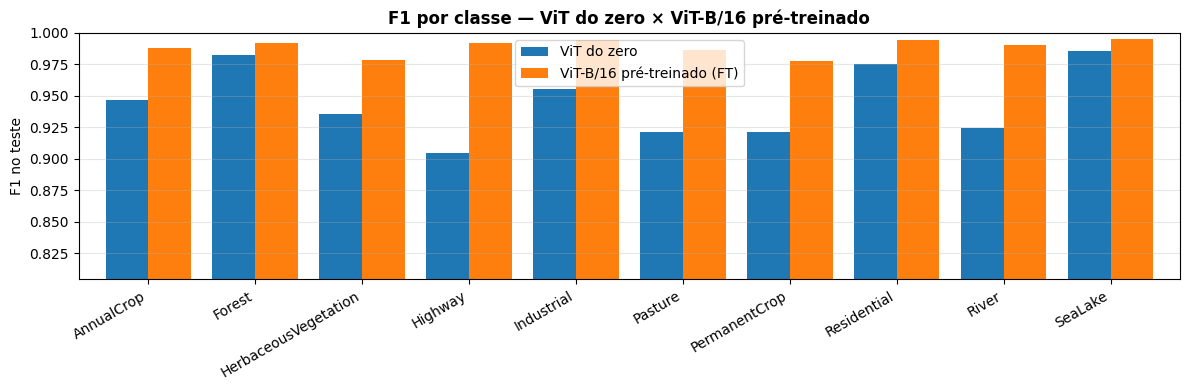

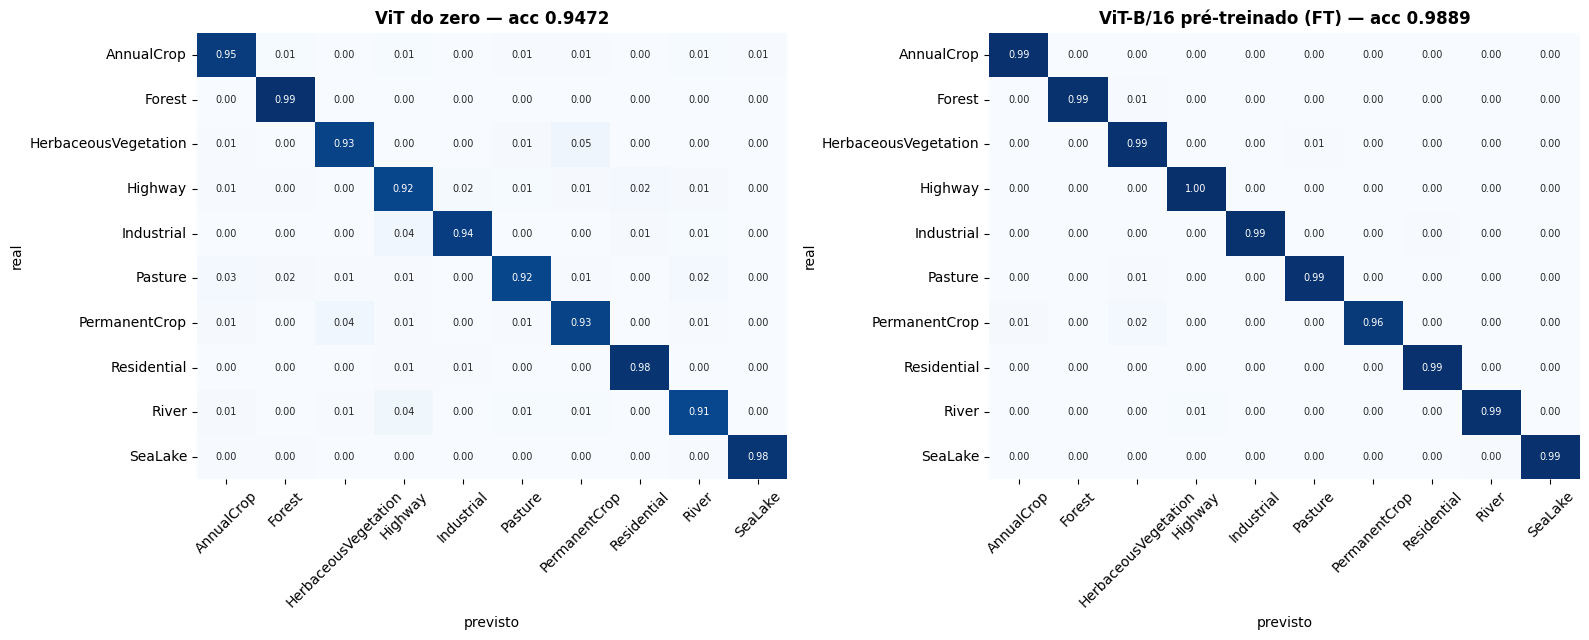

In [22]:
MAIN = ["ViT do zero", "ViT-B/16 pré-treinado (FT)"]

# Relatório por classe dos dois modelos principais
for name in MAIN:
    print(f"── {name}")
    print(classification_report(y_te.numpy(), preds_test[name], target_names=class_names, digits=4))

per_class = pd.DataFrame({name: f1_score(y_te.numpy(), preds_test[name], average=None) for name in RESULTS},
                         index=class_names)
per_class.to_csv(RES_DIR / "f1_por_classe.csv")
display(per_class.style.format("{:.3f}").background_gradient(cmap="RdYlGn", vmin=0.5, vmax=1.0))

ax = per_class[MAIN].plot.bar(figsize=(12, 4), width=0.8)
ax.set_ylabel("F1 no teste"); ax.set_ylim(max(0, per_class[MAIN].values.min() - 0.1), 1.0)
ax.set_title("F1 por classe — ViT do zero × ViT-B/16 pré-treinado", fontweight="bold"); ax.grid(axis="y", alpha=.3)
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); savefig("f1_por_classe.png"); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for ax, name in zip(axes, MAIN):
    cm = confusion_matrix(y_te.numpy(), preds_test[name], normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", ax=ax, cbar=False, vmin=0, vmax=1,
                xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 7})
    ax.set_title(f"{name} — acc {accuracy_score(y_te.numpy(), preds_test[name]):.4f}", fontweight="bold")
    ax.set_xlabel("previsto"); ax.set_ylabel("real")
    ax.tick_params(axis="x", rotation=45); ax.tick_params(axis="y", rotation=0)
plt.tight_layout(); savefig("matriz_confusao.png"); plt.show()

Top-5 confusões do ViT do zero (real → previsto):
     HerbaceousVegetation → PermanentCrop            26 imagens
                    River → Highway                  22 imagens
            PermanentCrop → HerbaceousVegetation     19 imagens
               Industrial → Highway                  18 imagens
                  Pasture → AnnualCrop               10 imagens


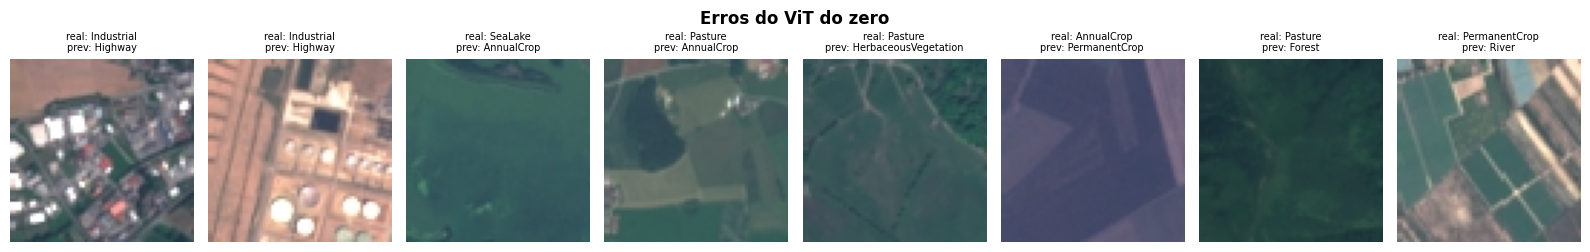

In [23]:
# Pares mais confundidos pelo ViT do zero (fora da diagonal)
cm = confusion_matrix(y_te.numpy(), preds_test["ViT do zero"])
off = [(cm[i, j], class_names[i], class_names[j]) for i in range(NUM_CLASSES) for j in range(NUM_CLASSES) if i != j]
print("Top-5 confusões do ViT do zero (real → previsto):")
for n, a, b in sorted(off, reverse=True)[:5]:
    print(f"   {a:>22} → {b:<22} {n:4d} imagens")

# Exemplos de erro
wrong = np.where(preds_test["ViT do zero"] != y_te.numpy())[0][:8]
if len(wrong):
    fig, axes = plt.subplots(1, len(wrong), figsize=(2 * len(wrong), 2.6))
    for ax, i in zip(np.atleast_1d(axes), wrong):
        ax.imshow(x_te[i].permute(1, 2, 0).numpy()); ax.axis("off")
        ax.set_title(f"real: {class_names[y_te[i]]}\nprev: {class_names[preds_test['ViT do zero'][i]]}", fontsize=7)
    plt.suptitle("Erros do ViT do zero", fontweight="bold"); plt.tight_layout(); savefig("erros_vit_scratch.png"); plt.show()

### 6.3 O modelo treinado usa a posição dos patches?

Avaliamos o ViT do zero (com PE) em imagens de teste com os patches **embaralhados**. Se a accuracy quase não cai, o
modelo decide por "quais texturas aparecem" (saco de patches); se cai muito, ele depende da **configuração
espacial**. O modelo sem PE, por construção (§3.1), dá exatamente o mesmo resultado nos dois casos.

In [24]:
set_seed()
perm = torch.randperm(64)
x_te_shuf = shuffle_patches(x_te.float(), 8, perm).round().to(torch.uint8)
shuf_rows = []
for name in ("ViT do zero", "ViT do zero sem PE"):
    r = RESULTS[name]
    _, acc_o, _ = predict(r["model"], r["logits_fn"], r["prep"], x_te, y_te)
    _, acc_s, _ = predict(r["model"], r["logits_fn"], r["prep"], x_te_shuf, y_te)
    shuf_rows.append({"Modelo": name, "Acc original": acc_o, "Acc patches embaralhados": acc_s, "Queda (p.p.)": 100 * (acc_o - acc_s)})
shuf_table = pd.DataFrame(shuf_rows).set_index("Modelo")
shuf_table.to_csv(RES_DIR / "teste_patches_embaralhados.csv")
display(shuf_table.style.format({"Acc original": "{:.4f}", "Acc patches embaralhados": "{:.4f}", "Queda (p.p.)": "{:.1f}"}))

,Acc original,Acc patches embaralhados,Queda (p.p.)
Modelo,,,
ViT do zero,0.9472,0.9426,0.5
ViT do zero sem PE,0.9428,0.9428,0.0


### 6.4 Leitura dos resultados

A tabela da §6.2 responde três perguntas, e as conclusões escritas na §8 se apoiam nela:

1. **Pré-treino × do zero com todos os dados** — a diferença de accuracy/F1 entre as linhas "ViT do zero" e
   "ViT-B/16 pré-treinado (FT)" mede o valor do pré-treino em ImageNet-21k para um domínio de satélite. A coluna de
   parâmetros e de inferência mostra o custo: ~30× mais parâmetros e throughput muito menor.
2. **Poucos dados** — a queda de cada modelo ao passar de 100% para 10% do treino mede a dependência de dados. O
   argumento clássico (Aula 04, *data hunger*) prevê que o ViT do zero perde muito mais que o pré-treinado.
3. **Positional encoding** — "ViT do zero" × "ViT do zero sem PE" e a tabela da §6.3 mostram se a configuração
   espacial importa no EuroSAT ou se texturas bastam.

**Resultados desta execução (T4):**

1. **Pré-treino × do zero (100% dos dados).** Accuracy **0,9889 × 0,9472** (+4,2 p.p.), F1 macro 0,9888 × 0,9452: a
   taxa de erro cai de 5,3% para 1,1% — **4,7× menos erros**. O custo: 31,5× mais parâmetros (85,8 × 2,72 M),
   17,7× mais tempo por época (210 × 11,9 s), inferência **23× mais lenta** (259 × 6.115 img/s) e 4,8 × 1,0 GB de
   VRAM. O tempo total de treino é parecido (~10 min) só porque o pré-treinado precisa de 3 épocas contra 50.
2. **Poucos dados (10% = 1.620 imagens).** O ViT do zero cai **8,9 p.p.** (0,9472 → 0,8587) e sobreajusta
   claramente (treino 0,977 × validação 0,850); o pré-treinado cai só **2,6 p.p.** (0,9889 → 0,9633). O ganho do
   pré-treino sobe de 4,2 para **10,5 p.p.** — e o **pré-treinado com 10% dos dados supera o do zero com 100%**
   (0,9633 × 0,9472). É o *data hunger* do ViT (Aula 04) medido.
3. **Positional encoding.** No total o PE vale só **+0,44 p.p.** (0,9472 × 0,9428) — com 5.400 imagens de teste o
   erro-padrão da accuracy é ~0,3 p.p., então essa diferença global sozinha não é conclusiva. O padrão por classe é
   mais claro: o PE ajuda nas **classes definidas por estruturas lineares** — F1 de *Highway* 0,904 × 0,881 (+2,3),
   *River* 0,924 × 0,904 (+2,0), *PermanentCrop* 0,922 × 0,908 (+1,4) — e empata ou perde levemente nas de
   textura (*Forest* 0,982 × 0,989, *Pasture* 0,921 × 0,928). Embaralhar os patches do teste tira só **0,5 p.p.** do
   ViT com PE (0,9472 → 0,9426). Conclusão: no EuroSAT a decisão é majoritariamente de **"saco de patches"** (quais
   texturas e cores aparecem); a configuração espacial só pesa nas classes de estrutura linear.
4. **Onde erram.** As 5 maiores confusões do ViT do zero são exatamente os pares de mesma paleta previstos na §1:
   *HerbaceousVegetation → PermanentCrop* (26), *River → Highway* (22), *PermanentCrop → HerbaceousVegetation* (19),
   *Industrial → Highway* (18) e *Pasture → AnnualCrop* (10). O pré-treinado praticamente zera essas confusões
   (*Highway* com recall 1,000); sua classe mais fraca é *PermanentCrop* (recall 0,961, confundida com vegetação
   herbácea e lavoura anual).

## 7. Attention maps

Três visualizações complementares:

- **Heatmap da matriz de atenção de uma head** (65×65 no ViT do zero): quem atende a quem.
- **Atenção do `[CLS]` para os patches, head a head**, na última camada, sobreposta à imagem (como na Aula 05 com o
  DINO) — mostra *onde* cada head procura evidência para a classificação.
- **Attention rollout** (Abnar & Zuidema, 2020; Aula 04) — propaga a atenção por todas as camadas somando a
  identidade (residual) e dá um mapa único do fluxo de informação patch → `[CLS]`.

In [25]:
def compute_attention_rollout(attentions):
    """Attention rollout (Aula 04): média das heads, + identidade (residual), produto em cascata pelas camadas."""
    result = torch.eye(attentions[0].size(-1), device=attentions[0].device)
    with torch.no_grad():
        for layer_attn in attentions:
            a = layer_attn[0].mean(dim=0)
            a = (a + torch.eye(a.size(-1), device=a.device)) / 2
            a = a / a.sum(dim=-1, keepdim=True)
            result = a @ result
    cls = result[0, 1:]
    g = int(math.sqrt(cls.numel()))
    hm = cls.reshape(g, g).float().cpu().numpy()
    return (hm - hm.min()) / (hm.max() - hm.min() + 1e-8)


def upsample(hm, size):
    t = torch.tensor(hm, dtype=torch.float32)[None, None]
    return F.interpolate(t, size=(size, size), mode="bilinear", align_corners=False)[0, 0].numpy()


def overlay(ax, img_hwc, hm, title):
    ax.imshow(img_hwc); ax.imshow(upsample(hm, img_hwc.shape[0]), cmap="jet", alpha=0.5)
    ax.set_title(title, fontsize=8); ax.axis("off")


def normalize(hm):
    return (hm - hm.min()) / (hm.max() - hm.min() + 1e-8)


@torch.no_grad()
def attentions_of(name, xb_uint8):
    r = RESULTS[name]; m = r["model"].eval()
    x = r["prep"](xb_uint8, train=False)
    if name.startswith("ViT-B/16"):
        out = m(pixel_values=x, output_attentions=True)
        return out.logits, [a.float() for a in out.attentions]
    logits, attns = m(x, return_attn=True)
    return logits, [a.float() for a in attns]


# Uma imagem de teste corretamente classificada por classe (determinístico)
correct_both = (preds_test["ViT do zero"] == y_te.numpy()) & (preds_test["ViT-B/16 pré-treinado (FT)"] == y_te.numpy())
SHOW_CLASSES = ["Highway", "River", "Industrial", "Residential", "AnnualCrop", "SeaLake"]
sample_idx = {}
for c in SHOW_CLASSES:
    cand = np.where((y_te.numpy() == label2id[c]) & correct_both)[0]
    cand = cand if len(cand) else np.where(y_te.numpy() == label2id[c])[0]
    if len(cand):
        sample_idx[c] = int(cand[0])
print(sample_idx)

{'Highway': 1, 'River': 11, 'Industrial': 0, 'Residential': 3, 'AnnualCrop': 9, 'SeaLake': 6}


### 7.1 Heatmap dos attention weights de uma head (ViT do zero)

Matriz completa $A \in \mathbb{R}^{65 \times 65}$ (linha = query, coluna = key; índice 0 = `[CLS]`) de uma head
da **primeira** e da **última** camada para uma imagem de *Highway*.

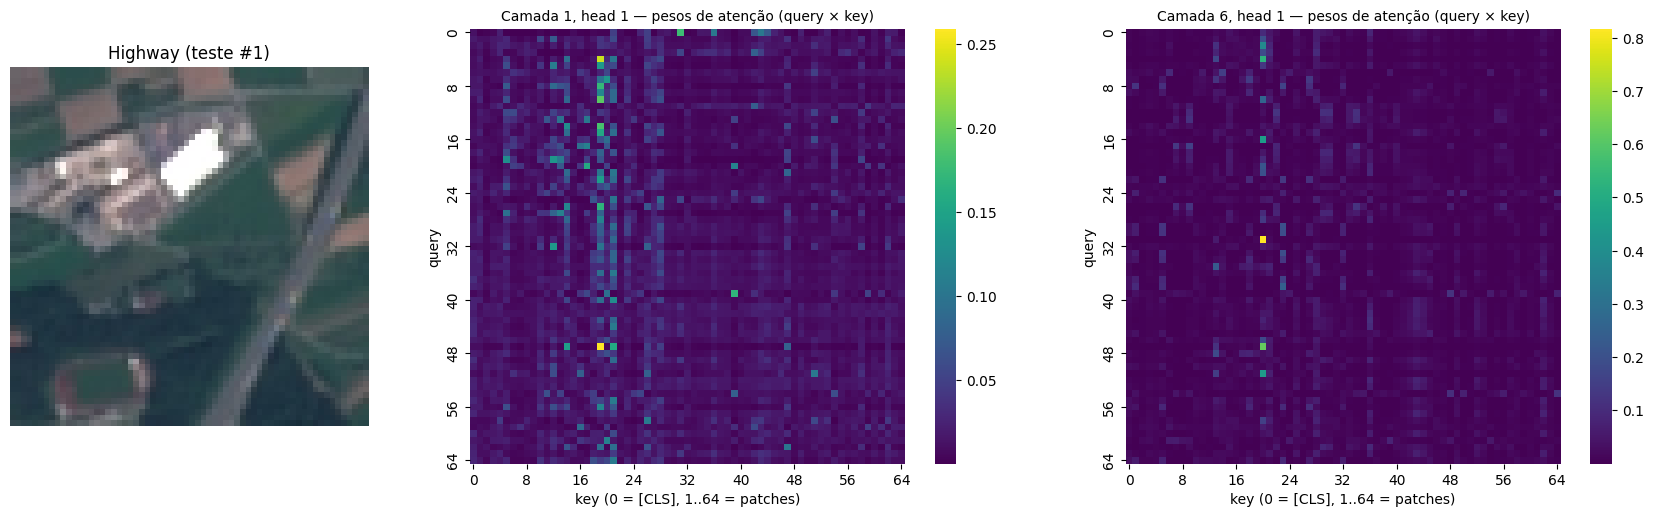

In [26]:
c0 = "Highway" if "Highway" in sample_idx else next(iter(sample_idx))
i0 = sample_idx[c0]
_, attns = attentions_of("ViT do zero", x_te[i0:i0 + 1])
HEAD = 0
fig, axes = plt.subplots(1, 3, figsize=(17, 5), gridspec_kw={"width_ratios": [0.6, 1, 1]})
axes[0].imshow(x_te[i0].permute(1, 2, 0).numpy()); axes[0].set_title(f"{c0} (teste #{i0})"); axes[0].axis("off")
for ax, layer in zip(axes[1:], (0, len(attns) - 1)):
    sns.heatmap(attns[layer][0, HEAD].cpu().numpy(), ax=ax, cmap="viridis", cbar=True,
                xticklabels=8, yticklabels=8, square=True)
    ax.set_title(f"Camada {layer + 1}, head {HEAD + 1} — pesos de atenção (query × key)", fontsize=10)
    ax.set_xlabel("key (0 = [CLS], 1..64 = patches)"); ax.set_ylabel("query")
plt.tight_layout(); savefig("heatmap_atencao_head.png"); plt.show()

### 7.2 `[CLS]` → patches por head e rollout — ViT do zero × ViT pré-treinado

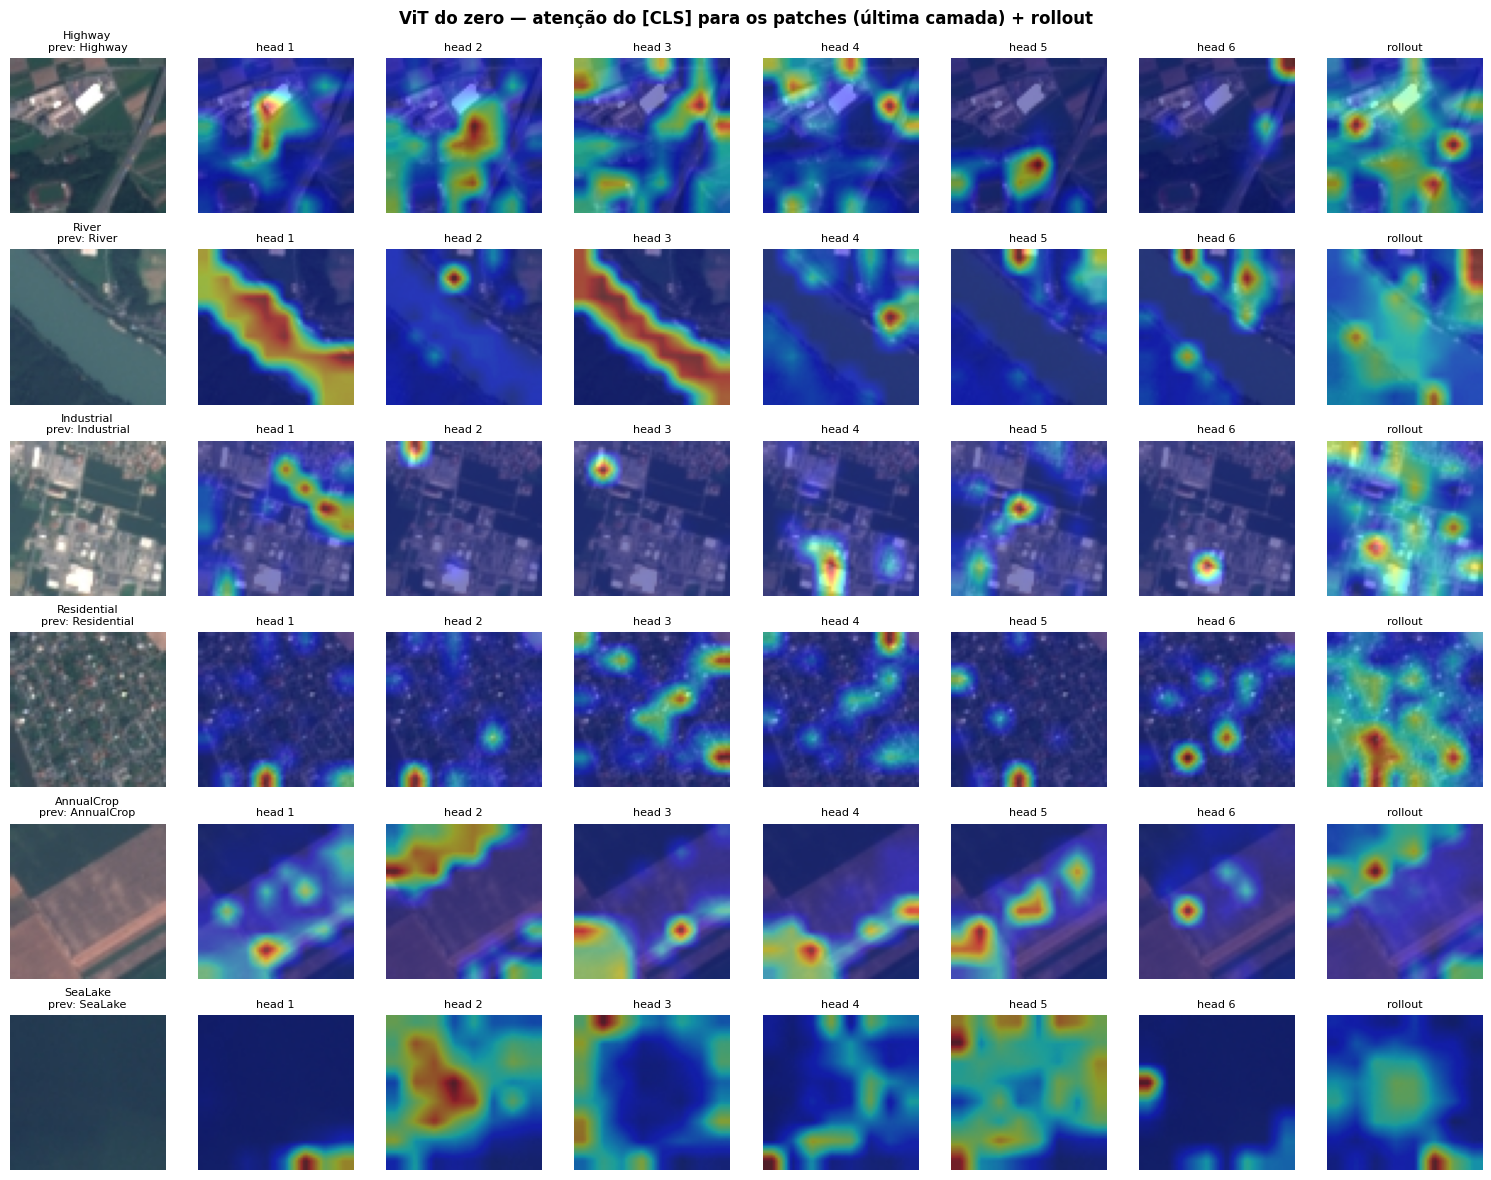

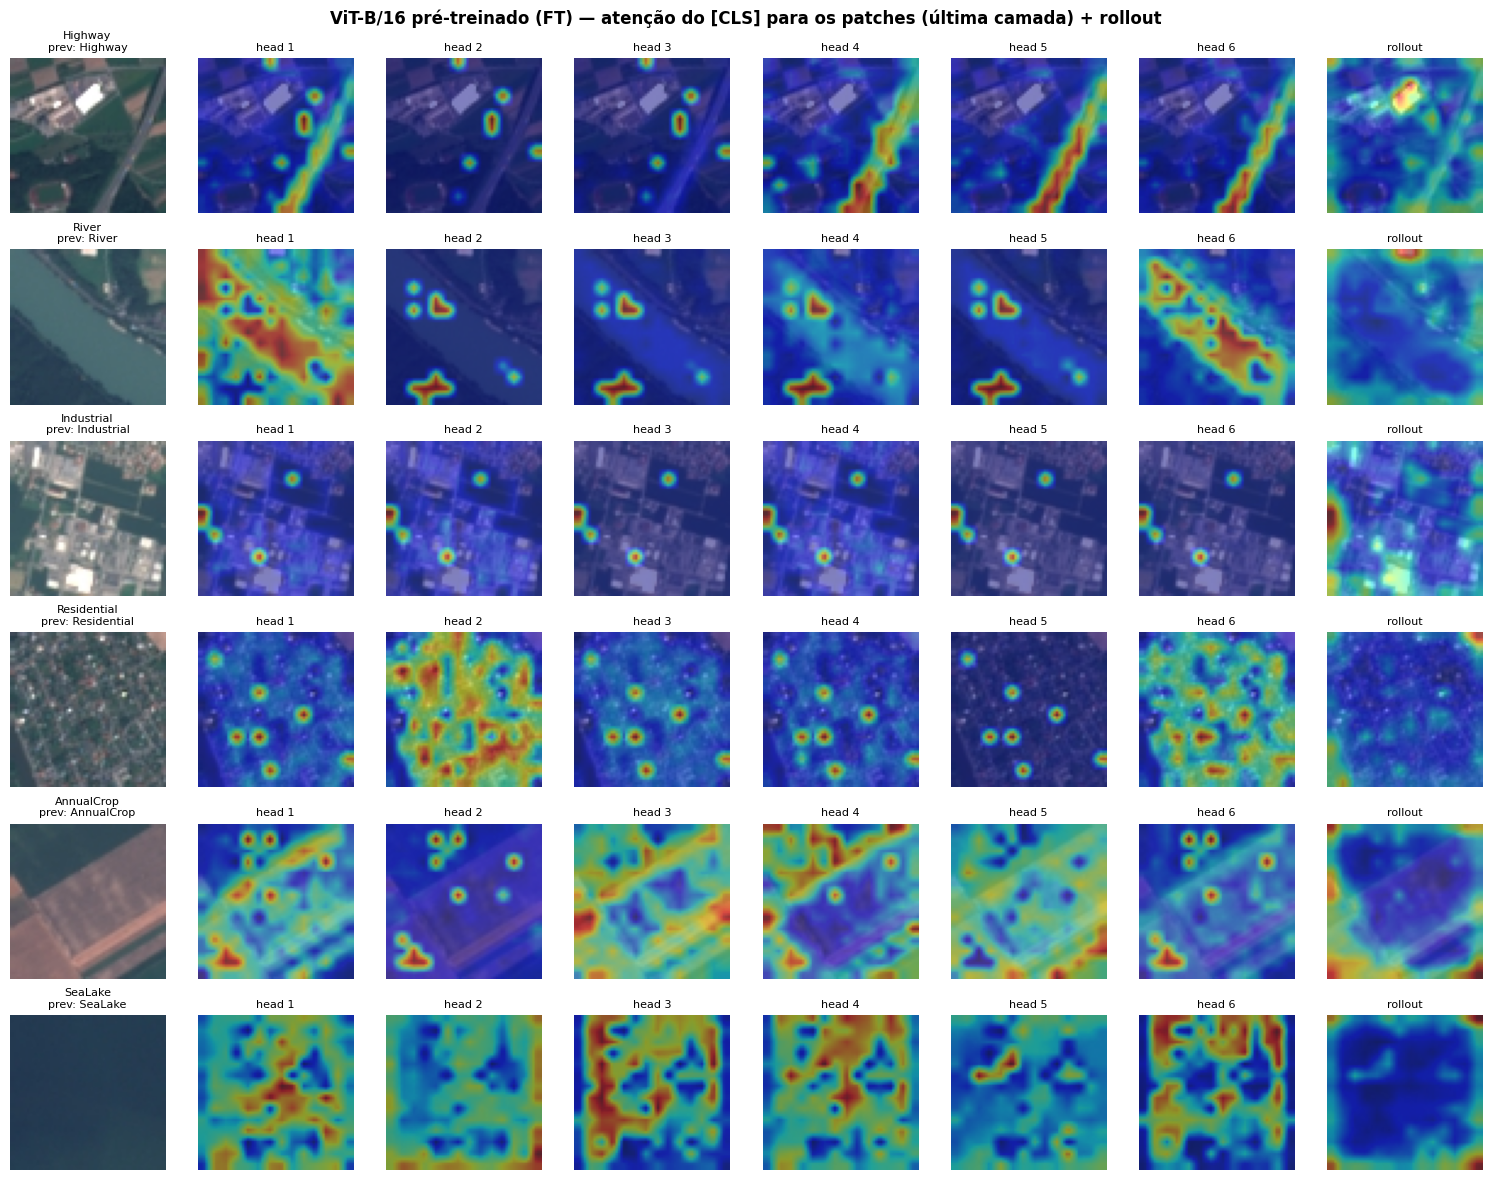

In [27]:
def plot_cls_heads(name, n_heads_show, fname):
    rows = list(sample_idx.items())
    ncols = 1 + n_heads_show + 1
    fig, axes = plt.subplots(len(rows), ncols, figsize=(1.9 * ncols, 2.0 * len(rows)))
    axes = np.atleast_2d(axes)
    for r, (c, i) in enumerate(rows):
        logits, attns = attentions_of(name, x_te[i:i + 1])
        pred = class_names[logits.argmax(-1).item()]
        img = x_te[i].permute(1, 2, 0).numpy()
        axes[r, 0].imshow(img); axes[r, 0].axis("off")
        axes[r, 0].set_title(f"{c}\nprev: {pred}", fontsize=8)
        last = attns[-1][0]                                   # [h, N, N]
        g = int(math.sqrt(last.size(-1) - 1))
        for h in range(n_heads_show):
            overlay(axes[r, 1 + h], img, normalize(last[h, 0, 1:].reshape(g, g).cpu().numpy()), f"head {h + 1}")
        overlay(axes[r, -1], img, compute_attention_rollout(attns), "rollout")
    plt.suptitle(f"{name} — atenção do [CLS] para os patches (última camada) + rollout", fontweight="bold")
    plt.tight_layout(); savefig(fname); plt.show()

plot_cls_heads("ViT do zero", 6, "atencao_cls_vit_scratch.png")
plot_cls_heads("ViT-B/16 pré-treinado (FT)", 6, "atencao_cls_vit_pretrained.png")

### 7.3 Distância média de atenção por camada (local × global)

Métrica do artigo original do ViT (Dosovitskiy et al., 2021, Fig. 7): para cada head, a distância espacial média
entre um patch e os patches a que ele atende, ponderada pelos pesos de atenção — expressa como fração do lado da
imagem para comparar os dois modelos (64 px e 224 px). Heads com distância pequena se comportam como **filtros
locais** (o viés indutivo que uma CNN já traz de fábrica); heads com distância grande integram **contexto global**.

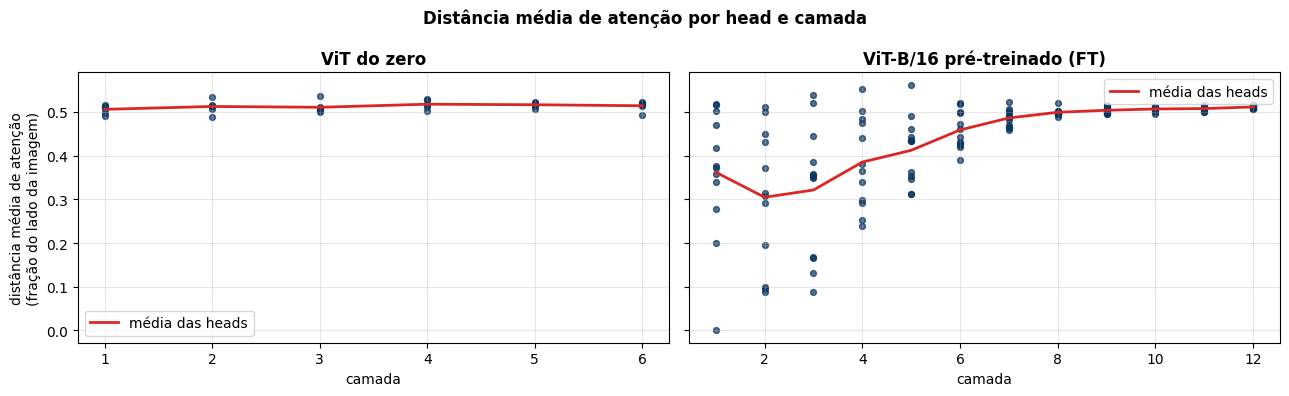

In [28]:
@torch.no_grad()
def mean_attention_distance(name, n_images=32):
    _, attns = attentions_of(name, x_te[:n_images])
    n_patch = attns[0].size(-1) - 1
    g = int(math.sqrt(n_patch))
    coords = torch.stack(torch.meshgrid(torch.arange(g), torch.arange(g), indexing="ij"), -1).reshape(-1, 2).float()
    dist = torch.cdist(coords, coords).to(attns[0].device) / g        # fração do lado da imagem
    out = []
    for a in attns:                                                  # a: [B, h, N, N]
        p = a[:, :, 1:, 1:]
        p = p / p.sum(-1, keepdim=True)                              # renormaliza sem o [CLS]
        out.append((p * dist).sum(-1).mean(dim=(0, 2)).cpu().numpy())  # [h]
    return np.stack(out)                                             # [camadas, h]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, name in zip(axes, MAIN):
    mad = mean_attention_distance(name)
    for layer in range(mad.shape[0]):
        ax.scatter([layer + 1] * mad.shape[1], mad[layer], s=18, alpha=0.7, color="#0A345D")
    ax.plot(range(1, mad.shape[0] + 1), mad.mean(1), color="#DC2626", lw=2, label="média das heads")
    ax.set_title(name, fontweight="bold"); ax.set_xlabel("camada"); ax.grid(alpha=.3); ax.legend()
axes[0].set_ylabel("distância média de atenção\n(fração do lado da imagem)")
plt.suptitle("Distância média de atenção por head e camada", fontweight="bold")
plt.tight_layout(); savefig("distancia_atencao.png"); plt.show()

### 7.4 O positional embedding aprendido codifica a grade 2D?

O PE do ViT do zero é uma tabela 1D (65 vetores) sem nenhuma noção de linha/coluna. Se o modelo precisou da posição,
a similaridade de cosseno entre o PE de um patch e os demais deve formar um padrão **2D** (alta perto do próprio
patch, na mesma linha e na mesma coluna) — como na Fig. 7 do ViT original.

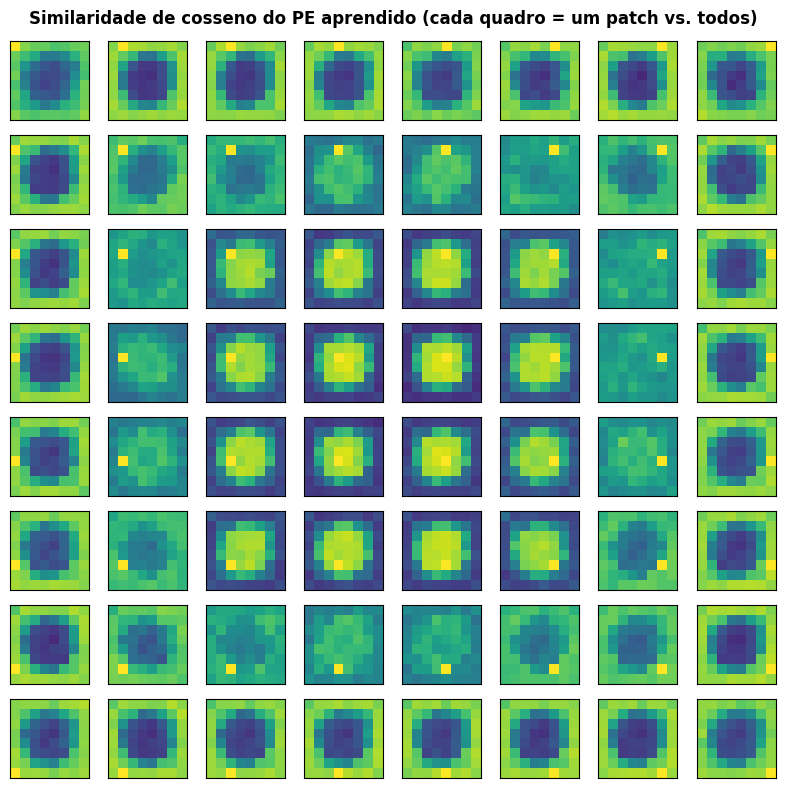

In [29]:
pos = RESULTS["ViT do zero"]["model"].pos_embed[0, 1:].detach().float().cpu()     # [64, d]
sim = F.cosine_similarity(pos[:, None], pos[None], dim=-1).numpy()                # [64, 64]
g = int(math.sqrt(pos.size(0)))
fig, axes = plt.subplots(g, g, figsize=(8, 8))
for i in range(g * g):
    ax = axes[i // g, i % g]
    ax.imshow(sim[i].reshape(g, g), cmap="viridis", vmin=-1, vmax=1); ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Similaridade de cosseno do PE aprendido (cada quadro = um patch vs. todos)", fontweight="bold")
plt.tight_layout(); savefig("pe_similaridade.png"); plt.show()

### 7.5 Interpretação — o que o modelo aprende a ponderar

**Heatmap de uma head (§7.1, *Highway* #1).** Na camada 1 a matriz já tem padrão de **colunas**: queries diferentes
atendem às mesmas keys (patches ~19–21, o galpão branco no canto superior esquerdo). Na camada 6 quase todas as
queries convergem para **um único patch** (peso de até 0,8). O modelo não constrói relações de vizinhança (a
diagonal é fraca): ele elege poucos patches salientes, de alto contraste, como "resumo" da imagem, e todos os tokens
leem desse *hub*.

**`[CLS]` → patches por classe (§7.2).**

- ***River*** — o ViT do zero tem duas heads (1 e 3) que **traçam o rio inteiro** com precisão: a evidência da classe
  é a faixa d'água. No pré-treinado, as heads 1 e 6 cobrem a faixa e as heads 2–5 fixam poucos pontos da margem.
- ***Highway*** — o contraste mais revelador. As heads 1, 4, 5 e 6 do pré-treinado **seguem exatamente a rodovia
  diagonal**. O ViT do zero **não olha a estrada**: as heads 1–2 fixam o galpão branco e as outras, campos ao redor. A
  predição está certa, mas por **contexto** (paisagem periurbana), não pela via. Isso explica as confusões
  *Industrial → Highway* (18) e *River → Highway* (22) do modelo do zero e o F1 de *Highway* de 0,904 contra 0,992 do
  pré-treinado.
- ***Industrial* e *Residential*** — pontos esparsos sobre telhados e construções; em *Residential* as heads se
  espalham pela malha de casas (cada head cobre casas diferentes). No pré-treinado em *Industrial* as 6 heads
  mostradas apontam para **os mesmos poucos patches** — redundância entre heads, compatível com os *attention sinks*
  descritos em ViTs grandes (tokens pouco informativos usados como depósito de atenção; Darcet et al., 2024).
- ***AnnualCrop*** — os dois modelos atendem às **fronteiras entre talhões** (head 2 do zero segue a borda do campo;
  heads 3–5 do pré-treinado realçam as bordas). A geometria retilínea dos talhões é a pista que separa lavoura anual
  de pastagem.
- ***SeaLake*** — atenção difusa e arbitrária nos dois: a imagem é homogênea e a decisão é pela cor média. Aqui o
  mapa de atenção **não é uma explicação útil**, uma limitação conhecida de ler atenção como explicação.
- **Rollout × última camada** — o rollout é mais difuso (soma a residual e faz a média das heads). No pré-treinado em
  *Highway* o rollout destaca o galpão, enquanto as heads da última camada destacam a estrada: as camadas
  intermediárias usam o galpão como contexto e a última camada busca a via. As duas visualizações contam partes
  diferentes da história, e é por isso que mostramos as duas.

**Distância média de atenção (§7.3) — hipótese refutada para o ViT do zero.** Todas as heads de todas as camadas do
ViT do zero ficam em ~0,50 do lado da imagem — atenção espalhada globalmente (atenção uniforme numa grade 8×8 daria
≈0,46). **Nenhuma head local surgiu.** O pré-treinado reproduz o padrão do artigo original do ViT: nas camadas 1–5
coexistem heads **locais** (0,0–0,2) e globais, e a partir da camada ~8 todas ficam globais. Leitura: com 16 mil
imagens o ViT do zero **não aprendeu o viés de localidade** que uma CNN tem de fábrica. Ele resolve o problema com
estatísticas globais de textura e cor, o que é coerente com a queda de só 0,5 p.p. ao embaralhar os patches. As
heads locais do pré-treinado vêm das 14 M imagens do ImageNet-21k: é o *data hunger* visto por dentro do modelo.

**Positional embedding aprendido (§7.4) — anéis concêntricos, não linhas e colunas.** A similaridade não forma o
padrão linha/coluna do ViT original: forma **anéis**. Os patches da borda são parecidos entre si, os do centro entre
si, e há um anel intermediário. A causa é a augmentation D4: flips e rotações de 90° tornam "linha" e "coluna"
indistinguíveis (o conteúdo de um canto pode aparecer em qualquer canto), e a única informação posicional estável
sob D4 é a **distância ao centro**. O modelo reconstruiu da topologia 2D exatamente a parte que a augmentation
permite — um PE **invariante ao grupo D4** aprendido só a partir dos dados.

**Síntese.** O ViT pré-treinado pondera as **estruturas geométricas corretas** (a estrada, o rio, as fronteiras dos
talhões), com hierarquia local → global. O ViT do zero pondera **poucos patches salientes e estatística global de
textura**: acerta 94,7%, mas por pistas menos específicas, o que aparece justamente nas confusões entre classes de
estrutura linear.

## 8. Análises escritas

### 8.1 Pré-treinamento de BERT × de ViT — o que cada estratégia maximiza

| | BERT (Aula 03) | ViT supervisionado (este notebook, in21k) | ViT auto-supervisionado (DINO, Aula 05) |
|---|---|---|---|
| Dado | texto não rotulado (BooksCorpus + Wikipedia) | 14 M imagens **rotuladas** em 21.843 classes | imagens sem rótulo |
| Tarefa | **MLM**: prever 15% dos tokens mascarados pelo contexto bidirecional; **NSP**: a sentença B segue A? | prever a classe da imagem pelo token `[CLS]` | *self-distillation*: o *student* (recortes locais) imita a distribuição do *teacher* (recortes globais, EMA) |
| Maximiza | $\log p(x_{\text{mascarado}} \mid x_{\text{contexto}})$ — verossimilhança de **reconstruir o sinal** a partir do contexto; NSP maximiza coerência entre sentenças | $\log p(y \mid x)$ — **discriminação entre categorias humanas** | concordância entre visões da mesma imagem — **invariância a recortes/augmentations** |
| Representação resultante | contextual, rica em sintaxe e semântica de *cada token*; útil para NER, QA, classificação | o `[CLS]` codifica "que objeto é este"; descarta o que não ajuda a separar as 21k classes (ex.: orientação) | features que agrupam semanticamente; atenção que segmenta o objeto sem rótulo (mapas emergentes da Aula 05) |

**Diferença essencial.** O BERT é pré-treinado de forma **auto-supervisionada e generativa sobre o próprio sinal**:
o rótulo é o token escondido, e dado não rotulado é praticamente infinito. O ViT original é pré-treinado de forma
**supervisionada e discriminativa**: o sinal de aprendizado vem de rótulos humanos, caros, e a representação herda o
viés desses rótulos (fotos de objetos centrados, tiradas do chão). Isso tem consequência direta no nosso domínio: o
in21k maximizou a separação de categorias de fotos naturais, não de padrões vistos de satélite — o que transfere são
as features genéricas de baixo/médio nível (bordas, texturas, cores), e por isso o fine-tuning **completo** (não só o
head) é necessário. A tentativa de transpor o MLM para imagens (BEiT, MAE — prever patches mascarados) e o DINO
aproximam o pré-treino de visão do paradigma do BERT: aprender com o próprio sinal, sem rótulos — o que é
especialmente atrativo em sensoriamento remoto, onde há petabytes de imagens e poucos rótulos.

### 8.2 DeiT e Swin — o que cada um resolve que o ViT original não resolve

**ViT original (Dosovitskiy et al., 2021)** tem dois problemas: (1) **fome de dados** — sem os vieses indutivos de
uma CNN (localidade, equivariância a translação), só supera ResNets quando pré-treinado em JFT-300M/ImageNet-21k;
treinado só no ImageNet-1k fica abaixo; (2) **custo quadrático e escala única** — atenção global entre todos os
$N$ tokens custa $O(N^2)$, e todos os blocos operam na mesma resolução (patch 16), o que impede imagens grandes e
não gera o mapa de features multi-escala que detecção e segmentação precisam.

- **DeiT (Touvron et al., 2021; Aula 05)** ataca o problema (1). Mostra que um ViT treinado **só no ImageNet-1k**
  atinge o nível das CNNs com uma receita de treino forte (RandAugment, Mixup, CutMix, *repeated augmentation*,
  *stochastic depth*, weight decay alto — a mesma família de regularização usada no nosso ViT do zero) e com
  **destilação por token**: um token `[DIST]`, paralelo ao `[CLS]`, aprende a imitar a predição (*hard
  distillation*) de um professor **CNN** — transferindo para o Transformer o viés indutivo da convolução sem mudar a
  arquitetura. Na inferência a CNN é descartada e as duas cabeças votam. O DeiT não muda a complexidade: continua
  $O(N^2)$ e de escala única.
- **Swin Transformer (Liu et al., 2021)** ataca o problema (2). A atenção é calculada dentro de **janelas locais**
  de $M \times M$ patches, o que torna o custo **linear** no número de patches ($O(N \cdot M^2)$); a cada bloco as
  janelas são **deslocadas** (*shifted windows*), permitindo troca de informação entre janelas vizinhas; e camadas de
  **patch merging** reduzem a resolução progressivamente (4×, 8×, 16×, 32×), produzindo uma **hierarquia multi-escala**
  como a de uma CNN — por isso o Swin serve de *backbone* para detecção/segmentação, algo que o ViT plano não faz
  bem. Também reintroduz localidade (viés indutivo) e usa *relative position bias* em vez de PE absoluto.

Resumo: **DeiT resolve eficiência de dados; Swin resolve eficiência computacional e multi-escala.** Para imagens de
satélite **grandes** (cenas inteiras de 10.000×10.000 px, segmentação de uso do solo), o Swin é a escolha natural; para
*tiles* pequenos como o EuroSAT, o ViT plano é suficiente e o DeiT seria o caminho para treinar do zero com mais
eficiência.

### 8.3 Quando ViT supera CNN e quando CNN é preferível — no EuroSAT

**CNN é preferível quando:**

- **Não há pré-treino disponível e há poucos dados.** A convolução impõe localidade e compartilhamento de pesos:
  "procure o mesmo padrão local em toda a imagem" é exatamente o prior certo para texturas de satélite. Um ViT do
  zero precisa *aprender* esse prior com os dados — e a §7.3 mostra que, com 16 mil imagens, **ele não aprendeu**:
  todas as suas heads são globais, enquanto o pré-treinado tem heads locais nas primeiras camadas. Com 10% dos dados
  o ViT do zero perde 8,9 p.p. contra 2,6 p.p. do pré-treinado (§6).
- **Imagens pequenas / baixa resolução e decisão por textura.** Em 64×64, com classes separadas majoritariamente por
  cor e textura, a vantagem principal do ViT — relacionar regiões distantes — pesa pouco; a ablação sem PE (§4.2 e
  §6.3) mostra que a configuração espacial pesa pouco: o PE vale +0,44 p.p. e embaralhar os patches custa 0,5 p.p.
- **Restrição de custo em produção.** Uma ResNet-18 (11 M parâmetros) ou EfficientNet-B0 (5 M) processa milhares de
  *tiles* por segundo em hardware modesto; o ViT-B/16 (86 M) exige upsampling para 224 px e é muito mais caro por
  imagem (259 × 6.115 img/s na tabela §6.2 — 23× mais lento que o nosso ViT pequeno). Para mapear um país inteiro periodicamente, isso importa.

**ViT supera CNN quando:**

- **Há pré-treino em larga escala** e o orçamento permite fine-tuning — o ViT pré-treinado escala melhor com dados e
  capacidade, e transfere bem mesmo para um domínio distante: 98,89% no teste, e 96,33% com apenas 10% dos rótulos (§6.2).
- **A evidência é global ou de longo alcance** (o pré-treinado segue a rodovia inteira na §7.2): estradas e rios que atravessam o *tile*, padrões de parcelamento
  urbano, relações entre regiões — a atenção relaciona quaisquer dois patches já na primeira camada.
- **Robustez**: ViTs são mais robustos a oclusões e perturbações de textura que CNNs, útil com nuvens parciais.
- **Multimodalidade e pré-treino auto-supervisionado** (MAE/DINO em imagens de satélite, bandas multiespectrais
  como tokens extras) — o Transformer trata qualquer entrada como sequência de tokens.

**Decisão para este domínio.** Com o EuroSAT completo e um checkpoint in21k disponível, o **ViT-B/16 pré-treinado**
é a escolha de maior acurácia; num cenário de **poucos rótulos sem pré-treino**, uma CNN pré-treinada seria preferível
ao ViT do zero, e em produção de alto volume o custo de inferência favorece uma CNN leve ou um ViT pequeno destilado
(DeiT-Ti). A escolha final é justificada com os números na §9.

### 8.4 Hiperparâmetros, o que os resultados revelam e o que mudaria

**Hiperparâmetros** — justificados nas tabelas das §4 e §5. Síntese: o ViT do zero precisa de **LR alto com
warmup, regularização forte e muitas épocas** (tudo para compensar a falta de viés indutivo); o pré-treinado
precisa do oposto — **LR baixo, pouca regularização, poucas épocas** — para não destruir o que já sabe.

**O que os resultados revelam** (detalhes na §6.4 e §7.5):

- O **pré-treino é o fator dominante**: +4,2 p.p. com todos os dados e +10,5 p.p. com 10% — e o pré-treinado com
  10% dos rótulos supera o do zero com 100%.
- O ViT do zero chega a 94,7% **sem aprender localidade** (heads todas globais) e decidindo quase como um "saco de
  patches" (−0,5 p.p. ao embaralhar); por isso erra justamente nas classes de estrutura linear (*Highway*, *River*).
- A augmentation D4 **moldou o próprio positional embedding** (anéis concêntricos invariantes a rotação/flip).
- O custo do pré-treinado é alto na inferência (23× mais lento), o que importa para mapear grandes áreas.

**O que eu mudaria / próximos experimentos:**

1. **Destilação estilo DeiT** — usar o ViT-B/16 fine-tunado (ou uma ResNet) como professor do ViT do zero com um
   token `[DIST]`: é o caminho direto para fechar o *gap* do modelo pequeno mantendo seu custo de inferência.
2. **Regularização de dados mais forte no ViT do zero** — CutMix/Mixup (Aula 04), RandAugment e *stochastic depth*;
   a receita completa do DeiT — principalmente no regime de 10%, onde o sobreajuste foi claro (0,977 × 0,850).
3. **Dar viés de localidade ao ViT pequeno** — a §7.3 mostrou que ele não aprende heads locais: um *stem*
   convolucional antes do patch embedding, ou atenção em janelas como no Swin, atacam isso diretamente.
4. **Pré-treino auto-supervisionado no domínio** — MAE ou DINO sobre imagens Sentinel-2 não rotuladas (abundantes),
   em vez de depender do ImageNet.
5. **Usar as 13 bandas espectrais** do EuroSAT-MS (infravermelho próximo separa vegetação de forma muito mais nítida
   que RGB) — no ViT basta mudar o `in_chans` do patch embedding.
6. **Comparação com CNN** (ResNet-50 / EfficientNet-B0 pré-treinadas) e com **Swin-T** no mesmo loop, para fechar a
   discussão ViT × CNN com números, e **fine-tuning eficiente** (LoRA, Aula 04) no ViT-B para reduzir custo.
7. **Resolução nativa no fine-tuning** — em vez de upsampling 64→224, interpolar os position embeddings do ViT-B
   para uma grade menor (ex. patch 16 em 128 px), reduzindo custo com pouca perda.
8. **Várias sementes** — repetir cada treino com 3–5 sementes para ter intervalo de confiança; diferenças pequenas
   como o efeito global do PE (+0,44 p.p.) só ficam conclusivas assim.

## 9. Resumo dos resultados e conclusão

In [30]:
summary = {
    "tabela": json.loads(table.drop(columns=["Pré-treino", "Dados de treino", "Melhor época"]).to_json(orient="index")),
    "patches_embaralhados": json.loads(shuf_table.to_json(orient="index")),
    "f1_por_classe": json.loads(per_class.to_json()),
    "hiperparametros": {"vit_scratch": {**VIT_CFG, **SCRATCH_HP}, "vit_pretrained": {"checkpoint": PT_CHECKPOINT, **PT_HP}},
    "smoke": SMOKE,
}
(RES_DIR / "metrics.json").write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")

acc = table["Accuracy teste"]; f1m = table["F1 macro"]
s, p = "ViT do zero", "ViT-B/16 pré-treinado (FT)"
s10, p10 = "ViT do zero (10% dados)", "ViT-B/16 pré-treinado (FT, 10% dados)"
print("════════ RESUMO ════════")
for name in table.index:
    print(f"{name:<40} acc {acc[name]:.4f} | F1 macro {f1m[name]:.4f} | "
          f"{table.loc[name, 'Parâmetros (M)']:.1f} M params | treino {table.loc[name, 'Tempo de treino (min)']:.1f} min")
print(f"\nGanho do pré-treino (100% dados): {100 * (acc[p] - acc[s]):+.2f} p.p. de accuracy")
print(f"Ganho do pré-treino (10% dados):  {100 * (acc[p10] - acc[s10]):+.2f} p.p. de accuracy")
print(f"Queda 100%→10% — do zero: {100 * (acc[s] - acc[s10]):.2f} p.p. | pré-treinado: {100 * (acc[p] - acc[p10]):.2f} p.p.")
print(f"Efeito do positional encoding: {100 * (acc[s] - acc['ViT do zero sem PE']):+.2f} p.p.")
print(f"\n⏱️ Tempo total do notebook: {(time.time() - T_START) / 60:.1f} min")

════════ RESUMO ════════
ViT do zero                              acc 0.9472 | F1 macro 0.9452 | 2.7 M params | treino 9.9 min
ViT do zero sem PE                       acc 0.9428 | F1 macro 0.9405 | 2.7 M params | treino 9.5 min
ViT-B/16 pré-treinado (FT)               acc 0.9889 | F1 macro 0.9888 | 85.8 M params | treino 10.5 min
ViT do zero (10% dados)                  acc 0.8587 | F1 macro 0.8541 | 2.7 M params | treino 1.5 min
ViT-B/16 pré-treinado (FT, 10% dados)    acc 0.9633 | F1 macro 0.9632 | 85.8 M params | treino 2.0 min

Ganho do pré-treino (100% dados): +4.17 p.p. de accuracy
Ganho do pré-treino (10% dados):  +10.46 p.p. de accuracy
Queda 100%→10% — do zero: 8.85 p.p. | pré-treinado: 2.56 p.p.
Efeito do positional encoding: +0.44 p.p.

⏱️ Tempo total do notebook: 35.7 min


**Conclusão.**

1. **Arquitetura escolhida para o domínio: ViT-B/16 pré-treinado no ImageNet-21k com fine-tuning completo.** Chega a
   **98,89% de accuracy e 0,989 de F1 macro** no teste, contra 94,72% / 0,945 do ViT construído do zero. A decisão se
   apoia nos dados: com só 10% dos rótulos (1.620 imagens) ele ainda faz **96,33%** — melhor que o ViT do zero com
   todos os dados. Em sensoriamento remoto, onde rotular é o gargalo, essa eficiência de dados é o argumento decisivo.
   O ViT do zero (2,7 M parâmetros, 23× mais rápido na inferência) é a alternativa quando o custo de inferência
   domina, e o caminho para melhorá-lo é a destilação estilo DeiT a partir do modelo grande.
2. **O que os attention maps mostram.** O pré-treinado pondera as estruturas que definem a classe — segue a rodovia,
   o rio e as fronteiras dos talhões —, com heads locais nas primeiras camadas e globais nas últimas. O ViT do zero
   acerta por pistas menos específicas (patches salientes, estatística global de textura): não aprendeu heads locais
   e quase não usa a posição dos patches (−0,5 p.p. ao embaralhá-los). Seu PE aprendeu uma codificação em anéis,
   invariante às rotações e flips da augmentation.
3. **Limitações** — abaixo.

**Limitações.** Uma única semente (variância entre execuções não medida); o ViT-B/16 recebe imagens 64 px ampliadas
para 224 px (informação não aumenta, só o custo); só as 3 bandas RGB; comparação sem uma CNN no mesmo loop
(coberta pela Atividade 3).

## Uso de IA

Houve uso de IA para auxílio no desenvolvimento do projeto.

## Referências

- Vaswani et al. (2017). *Attention Is All You Need*. arXiv:1706.03762.
- Dosovitskiy et al. (2021). *An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale* (ViT). arXiv:2010.11929.
- Touvron et al. (2021). *Training data-efficient image transformers & distillation through attention* (DeiT). arXiv:2012.12877.
- Liu et al. (2021). *Swin Transformer: Hierarchical Vision Transformer using Shifted Windows*. arXiv:2103.14030.
- Caron et al. (2021). *Emerging Properties in Self-Supervised Vision Transformers* (DINO). arXiv:2104.14294.
- Devlin et al. (2019). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding*. arXiv:1810.04805.
- Abnar & Zuidema (2020). *Quantifying Attention Flow in Transformers* (attention rollout). arXiv:2005.00928.
- Helber et al. (2019). *EuroSAT: A Novel Dataset and Deep Learning Benchmark for Land Use and Land Cover Classification*. IEEE JSTARS.
- Material das Aulas 02–05 da disciplina (Transformer do zero, BERT, ViT com Hugging Face, DeiT, DINO, EuroSAT).